# **Fake News Detection on Twitter using NLP and Machine Learning**


Develop a Fake News Detection System to analyze tweets and classify them as Real or Fake using Natural Language Processing (NLP) and Machine Learning models.

The data format --

Each sample in the train and test set has the following information:

*   The text of a tweet
*   A keyword from that tweet (although this may be blank!)
*   The location the tweet was sent from (may also be blank)

Columns

*   id - a unique identifier for each tweet
*   text - the text of the tweet
*   location - the location the tweet was sent from (may be blank)
*   keyword - a particular keyword from the tweet (may be blank)
*   target - in train.csv only, this denotes whether a tweet is about a real
    disaster (1) or not (0)

What are you predicting?

You are predicting whether a given tweet is about a real disaster or not. If so, predict a 1. If not, predict a 0.

In [2]:
# Data Loading and Manipulation
import pandas as pd

# Numerical computation
import numpy as np

# Text Cleaning and Preprocessing (tokenization, stopwords, stemming)
import re
import spacy
!pip install -u spacy
!python -m spacy download en_core_web_lg
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Feature Engineering + Text vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Word Embedding using word2vec
!pip install gensim
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# Model Training and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Generating visual representations of text data
from wordcloud import WordCloud

# Transformers
!pip install transformers
from transformers import BertTokenizer, BertModel
!pip install torch
import torch
from tqdm import tqdm

# may create restart pop up while installing gensim... so run tis cell multiple times even try to restart runtime


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **Data Exploration and Cleaning**
Load the dataset using pandas and inspect its structure.
Check for null values and handle missing data appropriately.
Perform basic exploratory data analysis (EDA) using visualizations like bar plots, histograms, and word clouds to understand the distribution of fake and real tweets.

1.   Load the dataset using pandas and inspect its structure.
2.   Check for null values and handle missing data appropriately.
3.   Perform basic exploratory data analysis (EDA) using visualizations like
     bar plots, histograms, and word clouds to understand the distribution of
     fake and real tweets.




In [3]:
# Load the dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('train (1).csv')

# Inspect the structure
print('\n')
print("Dataset structure:")
df.info()
print('\n')
print("First few rows of the dataset:")
print(df.head())
print('\n')
print("Last few rows of the dataset:")
print(df.tail())
print('\n')
print(f"\nTotal tweets:{df.shape[0]}")
print('\n')
print(f"\nUnique tweets:{df['text'].nunique()}")
print('\n')
print(f"\nTotal real tweets:{df['target'].value_counts()[1]}")
print('\n')
print(f"\nTotal fake tweets:{df['target'].value_counts()[0]}")
print('\n')

Saving train (1).csv to train (1).csv


Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


First few rows of the dataset:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1

In [4]:
# Check for null values
print("\nNull values per column:")
print(df.isnull().sum())
print('\n')

# Handle missing data (Example: fill missing location with 'unknown', keyword with 'none')
df['location'] = df['location'].fillna('unknown')
df['keyword'] = df['keyword'].fillna('none')

# just to recheck
print("\nNull values after handling:")
print(df.isnull().sum())
print('\n')


Null values per column:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64



Null values after handling:
id          0
keyword     0
location    0
text        0
target      0
dtype: int64




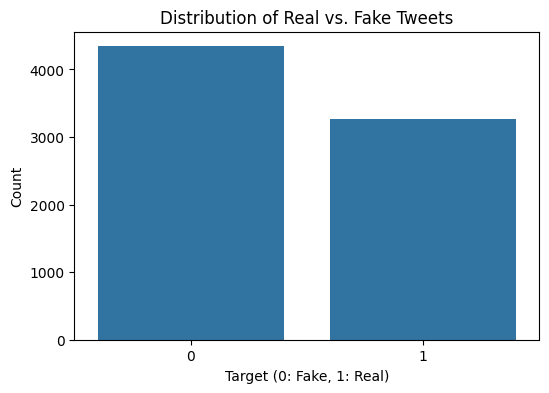

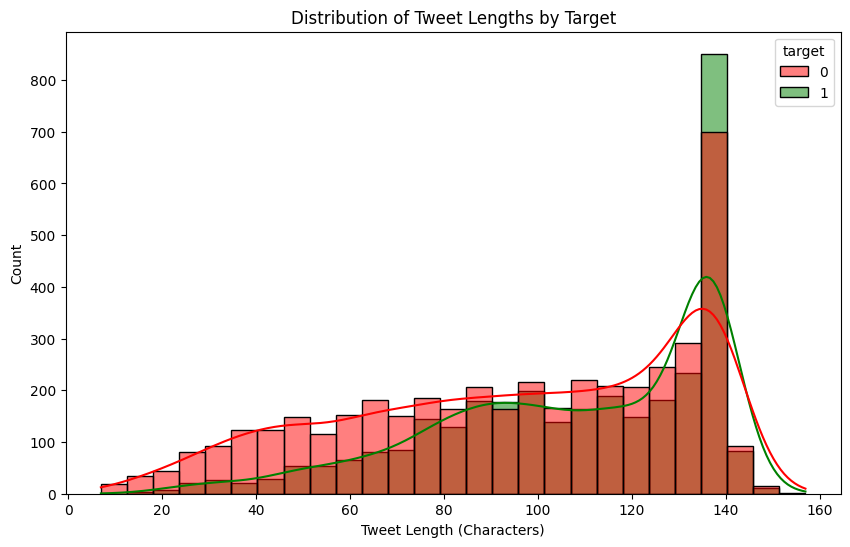

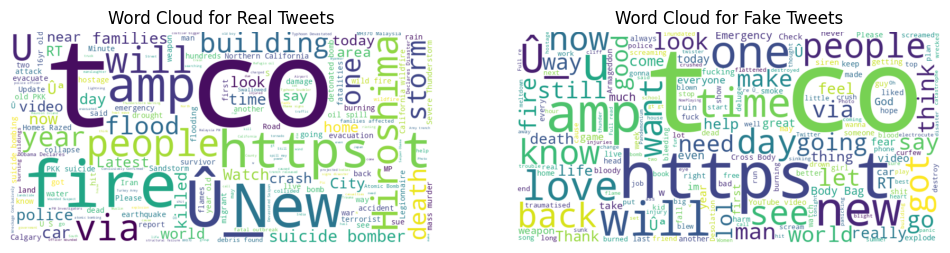

In [5]:
print ('\n')
# Basic EDA

# Distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Real vs. Fake Tweets')
plt.xlabel('Target (0: Fake, 1: Real)')
plt.ylabel('Count')
plt.show()
print('\n')

# Distribution of tweet lengths (character count)
# Histograms show the character length distribution by class
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(x='text_length',data=df, hue='target', kde=True, palette = {0:"red", 1:"green"})
plt.title('Distribution of Tweet Lengths by Target')
plt.xlabel('Tweet Length (Characters)')
plt.ylabel('Count')
plt.show()
print('\n')

# Wordclouds give a quickveiw of most frequent words used in real vs fake tweets
real_tweets = df[df['target'] == 1]['text'].str.cat(sep=' ')
fake_tweets = df[df['target'] == 0]['text'].str.cat(sep=' ')

wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_tweets)
wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_tweets)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Real Tweets')
print('\n')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Fake Tweets')
plt.show()
print('\n')

## **Text Preprocessing**

*   Remove punctuation, special characters, and numbers from tweets using
     regex.
*   Convert text to lowercase and remove stopwords using nltk.
*    Apply stemming and lemmatization to normalize text using nltk and spacy.
*    Visualize the most frequently used words with wordcloud and matplotlib.

In [6]:
# 1. BY REGEX AND NLTK
# Load important functions
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Text Preprocessing function using spacy
def preprocess_text_nltk(text):
    # Remove punctuation, special characters, and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    # Remove urls from the tweets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Convert to lowercase
    text = text.lower()
    # Creating tokens
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Apply lemmatization and stemming
    tokens = [lemmatizer.lemmatize(stemmer.stem(word)) for word in tokens]
    # Join tokens back into a string
    return ' '.join(tokens)

# Apply preprocessing to the text column
df['cleaned_text_nltk'] = df['text'].apply(preprocess_text_nltk)

print("\nFirst few rows after text preprocessing:")
print(df[['text', 'cleaned_text_nltk']].head())
print('\n')
print('-'*100)
print('\n')


# 2. BY SPACY
# Load the large model
nlp = spacy.load('en_core_web_lg')

# Text Preprocessing function using spacy
def preprocess_text_spacy(text):
  # Remove urls from the tweets
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  # Process the text apply lowercase
  doc = nlp(text.lower())
  # Remove  stopwors, punctuation, special characters, numbers
  # No need of stemming
  tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha and not token.is_digit and len(token.text)>1]
  # Join tokens back into a string
  return ' '.join(tokens)

# Apply preprocessing to the text column
df['cleaned_text_spacy'] = df['text'].apply(preprocess_text_spacy)

print("\nFirst few rows after text preprocessing:")
print(df[['text', 'cleaned_text_spacy']].head())
print('\n')


First few rows after text preprocessing:
                                                text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   
3  13,000 people receive #wildfires evacuation or...   
4  Just got sent this photo from Ruby #Alaska as ...   

                                   cleaned_text_nltk  
0           deed reason earthquak may allah forgiv u  
1               forest fire near la rong sask canada  
2  resid ask shelter place notifi offic evacu she...  
3        peopl receiv wildfir evacu order california  
4  got sent photo rubi alaska smoke wildfir pour ...  


----------------------------------------------------------------------------------------------------



First few rows after text preprocessing:
                                                text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near L

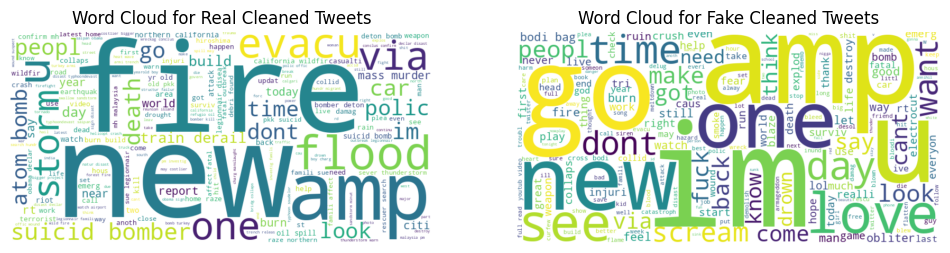



--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------






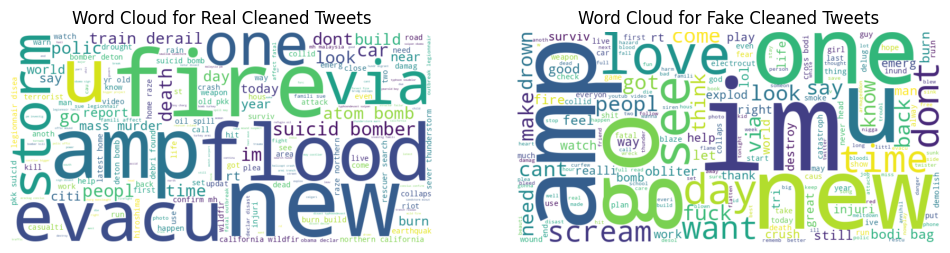




Note the difference -- first one is using regex and nltk and the second one is using spacy




In [7]:
# Visualize the most frequently used words by target in cleaned text by nltk
real_cleaned_text = df[df['target'] == 1]['cleaned_text_nltk'].str.cat(sep=' ')
fake_cleaned_text = df[df['target'] == 0]['cleaned_text_nltk'].str.cat(sep=' ')

wordcloud_real_cleaned = WordCloud(width=800, height=400, background_color='white').generate(real_cleaned_text)
wordcloud_fake_cleaned = WordCloud(width=800, height=400, background_color='white').generate(fake_cleaned_text)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_real_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Real Cleaned Tweets')
print('\n')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_fake_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Fake Cleaned Tweets')
plt.show()
print('\n')
print('-'*200)
print('\n')


# Visualize the most frequently used words by target in cleaned text by spacy
real_cleaned_text = df[df['target'] == 1]['cleaned_text_nltk'].str.cat(sep=' ')
fake_cleaned_text = df[df['target'] == 0]['cleaned_text_nltk'].str.cat(sep=' ')

wordcloud_real_cleaned = WordCloud(width=800, height=400, background_color='white').generate(real_cleaned_text)
wordcloud_fake_cleaned = WordCloud(width=800, height=400, background_color='white').generate(fake_cleaned_text)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_real_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Real Cleaned Tweets')
print('\n')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_fake_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Fake Cleaned Tweets')
plt.show()
print('\n')

print ('\nNote the difference -- first one is using regex and nltk and the second one is using spacy')
print('\n')

## **Feature Extraction**


*   Transform the preprocessed text into numerical features using:
    *   **Bag of Words (CountVectorizer)**
    *   **TF-IDF (Term Frequency-Inverse Document Frequency)**
*   Explore word embeddings (e.g., Word2Vec or pre-trained BERT embeddings
    using **transformers**) for better feature extraction.

In [8]:
# 1. FOR NLTK
print('\n')
print('This is for nltk --')
# Bag of Words (CountVectorizer)
count_vectorizer = CountVectorizer(max_features = 5000, min_df = 2, max_df = 0.97, stop_words = 'english')
# Limit to top 5000 frequent words, Ignore words in 2 documents, Ignore words in >97% documents, Remove standard English stpwords
X_counts_nltk = count_vectorizer.fit_transform(df['cleaned_text_nltk'])
y = df['target']

print('\nBy Countvectorizer')
print("Shape of CountVectorizer features:", X_counts_nltk.shape)
print("Shape of target variable:", y.shape)
print("First five features are here:",count_vectorizer.get_feature_names_out()[:5])
print('\n')

# TF-IDF (Term Frequency-Inverse Document Frequency)
tfidf_vectorizer = TfidfVectorizer(max_features = 5000, min_df = 2, max_df = 0.97, stop_words = 'english', sublinear_tf = True)
# Limit to top 5000 frequent words, Ignore words in <2 documents, Ignore words in >97% documents, Remove standard English stpwords, Also setting sublinear_tf
X_tfidf_nltk = tfidf_vectorizer.fit_transform(df['cleaned_text_nltk'])
y = df['target']

print('\nBy TF-IDF Vectorization')
print("Shape of TfidfVectorizer features:", X_tfidf_nltk.shape)
print("Shape of target variable:", y.shape)
print("First five features are here:",tfidf_vectorizer.get_feature_names_out()[:5])
print('\n')


print('-'*100)


# 2. FOR SPACY
print('\n')
print('This is for spacy --')
# Bag of Words (CountVectorizer)
count_vectorizer = CountVectorizer(max_features = 5000, min_df = 2, max_df = 0.97, stop_words = 'english')
# Limit to top 5000 frequent words, Ignore words in <2 documents, Ignore words in >97% documents, Remove standard English stpwords
X_counts_spacy = count_vectorizer.fit_transform(df['cleaned_text_spacy'])
y = df['target']

print('\nBy countvectorizer -- ')
print("Shape of CountVectorizer features:", X_counts_spacy.shape)
print("Shape of target variable:", y.shape)
print("First five features are here:",count_vectorizer.get_feature_names_out()[:5])
print('\n')

# TF-IDF (Term Frequency-Inverse Document Frequency)
tfidf_vectorizer = TfidfVectorizer(max_features = 5000, min_df = 2, max_df = 0.97, stop_words = 'english', sublinear_tf = True)
# Limit to top 5000 frequent words, Ignore words in <2 documents, Ignore words in >97% documents, Remove standard English stpwords, Also setting sub linear_tf
X_tfidf_spacy = tfidf_vectorizer.fit_transform(df['cleaned_text_spacy'])
y = df['target']


print('\nBy TF-IDF Vectorization')
print("Shape of TfidfVectorizer features:", X_tfidf_spacy.shape)
print("Shape of target variable:", y.shape)
print("First five features are here:",tfidf_vectorizer.get_feature_names_out()[:5])
print('\n')

# Now we have X_counts_nltk & X_counts_spacy (Bag of Words features) and X_tfidf_nltk & X_tfidf_spacy (TF-IDF features) -- a sparse matrix
# and y (target variable) ready for model training.



This is for nltk --

By Countvectorizer
Shape of CountVectorizer features: (7613, 5000)
Shape of target variable: (7613,)
First five features are here: ['aa' 'ab' 'aba' 'abandon' 'abbott']



By TF-IDF Vectorization
Shape of TfidfVectorizer features: (7613, 5000)
Shape of target variable: (7613,)
First five features are here: ['aa' 'ab' 'aba' 'abandon' 'abbott']


----------------------------------------------------------------------------------------------------


This is for spacy --

By countvectorizer -- 
Shape of CountVectorizer features: (7613, 4815)
Shape of target variable: (7613,)
First five features are here: ['aa' 'ab' 'aba' 'abandon' 'abbott']



By TF-IDF Vectorization
Shape of TfidfVectorizer features: (7613, 4815)
Shape of target variable: (7613,)
First five features are here: ['aa' 'ab' 'aba' 'abandon' 'abbott']




In [9]:
# Word embedding using word2vec by cbow and skip-gram
# Tokenize the cleaned text for Word2Vec training
df['tokenized_text_nltk'] = df['cleaned_text_nltk'].str.split()
df['tokenized_text_spacy'] = df['cleaned_text_spacy'].str.split()

# Combine tokenized lists for training
all_tokens_nltk = df['tokenized_text_nltk'].tolist()
all_tokens_spacy = df['tokenized_text_spacy'].tolist()


# Function to train Word2Vec model (CBOW or Skip-gram)
def train_word2vec_model(sentences, vector_size, window, min_count, sg):
  model = Word2Vec(sentences=sentences, vector_size=vector_size, window=window, min_count=min_count, sg=sg)
  return model

# Train CBOW model using NLTK cleaned text
print("Training CBOW model (NLTK cleaned text)...")
cbow_model_nltk = train_word2vec_model(all_tokens_nltk, vector_size=100, window=5, min_count=1, sg=0)
print("CBOW model training complete.")

# Train Skip-gram model using NLTK cleaned text
print("Training Skip-gram model (NLTK cleaned text)...")
skipgram_model_nltk = train_word2vec_model(all_tokens_nltk, vector_size=100, window=5, min_count=1, sg=1)
print("Skip-gram model training complete.")

# Train CBOW model using SpaCy cleaned text
print("Training CBOW model (SpaCy cleaned text)...")
cbow_model_spacy = train_word2vec_model(all_tokens_spacy, vector_size=100, window=5, min_count=1, sg=0)
print("CBOW model training complete.")

# Train Skip-gram model using SpaCy cleaned text
print("Training Skip-gram model (SpaCy cleaned text)...")
skipgram_model_spacy = train_word2vec_model(all_tokens_spacy, vector_size=100, window=5, min_count=1, sg=1)
print("Skip-gram model training complete.")


# Function to get document vectors by averaging word vectors
def get_document_vector(tokens, model):
  # Filter out tokens that are not in the vocabulary
  word_vectors = [model.wv[token] for token in tokens if token in model.wv]
  if len(word_vectors) == 0:
    return np.zeros(model.wv.vector_size) # Return zero vector if no words in vocabulary
  return np.mean(word_vectors, axis=0)

# Create document vectors for CBOW (NLTK)
X_cbow_nltk = np.vstack([get_document_vector(tokens, cbow_model_nltk) for tokens in df['tokenized_text_nltk']])
print("\nShape of CBOW (NLTK) document vectors:", X_cbow_nltk.shape)

# Create document vectors for Skip-gram (NLTK)
X_skipgram_nltk = np.vstack([get_document_vector(tokens, skipgram_model_nltk) for tokens in df['tokenized_text_nltk']])
print("Shape of Skip-gram (NLTK) document vectors:", X_skipgram_nltk.shape)

# Create document vectors for CBOW (SpaCy)
X_cbow_spacy = np.vstack([get_document_vector(tokens, cbow_model_spacy) for tokens in df['tokenized_text_spacy']])
print("Shape of CBOW (SpaCy) document vectors:", X_cbow_spacy.shape)

# Create document vectors for Skip-gram (SpaCy)
X_skipgram_spacy = np.vstack([get_document_vector(tokens, skipgram_model_spacy) for tokens in df['tokenized_text_spacy']])
print("Shape of Skip-gram (SpaCy) document vectors:", X_skipgram_spacy.shape)

# Now we have X_cbow_nltk & X_cbow_spacy (Bag of Words features) and X_skipgram_nltk & X_skipgram_spacy (TF-IDF features)
# ready for model training.

Training CBOW model (NLTK cleaned text)...
CBOW model training complete.
Training Skip-gram model (NLTK cleaned text)...
Skip-gram model training complete.
Training CBOW model (SpaCy cleaned text)...
CBOW model training complete.
Training Skip-gram model (SpaCy cleaned text)...
Skip-gram model training complete.

Shape of CBOW (NLTK) document vectors: (7613, 100)
Shape of Skip-gram (NLTK) document vectors: (7613, 100)
Shape of CBOW (SpaCy) document vectors: (7613, 100)
Shape of Skip-gram (SpaCy) document vectors: (7613, 100)


In [11]:
# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Function to generate BERT embeddings in batches
def get_bert_embeddings(texts, batch_size=16):
  bert_model.eval()  # Set the model to evaluation mode
  embeddings = []
  for i in tqdm(range(0, len(texts), batch_size), desc="Generating BERT Embeddings"):
    batch_texts = texts[i:i+batch_size]
    encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt', max_length=128)

    with torch.no_grad():
      output = bert_model(**encoded_input)

    # Get the embeddings for the [CLS] token (representing the whole sentence)
    # Alternatively, you could average the embeddings of all tokens
    batch_embeddings = output.last_hidden_state[:, 0, :].squeeze().numpy()
    embeddings.extend(batch_embeddings)
  return np.array(embeddings)

# Generate BERT embeddings for cleaned text using nltk preprocessing
print("\nGenerating BERT embeddings using Nltk cleaned text...")
X_bert_nltk = get_bert_embeddings(df['cleaned_text_nltk'].tolist())
print("\nShape of BERT embeddings using Nltk:", X_bert_nltk.shape)

# Generate BERT embeddings for cleaned text using SpaCy preprocessing
print("\nGenerating BERT embeddings using SpaCy cleaned text...")
X_bert_spacy = get_bert_embeddings(df['cleaned_text_spacy'].tolist())
print("\nShape of BERT embeddings using Spacy:", X_bert_spacy.shape)

# Now X_ber_nltk & X_bert_spacy contains the BERT embeddings for cleaned text by nltk &spacy respectively
# You can use this as a feature set for your machine learning models.


Generating BERT embeddings using Nltk cleaned text...


Generating BERT Embeddings: 100%|██████████| 476/476 [14:03<00:00,  1.77s/it]



Shape of BERT embeddings using Nltk: (7613, 768)

Generating BERT embeddings using SpaCy cleaned text...


Generating BERT Embeddings: 100%|██████████| 476/476 [09:10<00:00,  1.16s/it]


Shape of BERT embeddings using Spacy: (7613, 768)


## **Model Building**

*   Split the data into training and testing sets using **train_test_split**.
*   Train different machine learning models, including:
    *   **Logistic Regression**
    *   **Support vector Machine**
    *   **Naive Bates Classifier**
*   Evaluate model performance using accuracy, precision, recall, F1-score, and
    confusion matrix.

In [12]:
print('\n')

# 1. BY NLTK
print('Train-Test split for features and targets through nltk --')
print('\n')

# Using CountVectorizer features
print('Train-Test split for features and targets through nltk using countvectorizer --')
X_train_counts_nltk, X_test_counts_nltk, y_train_counts, y_test_counts = train_test_split(X_counts_nltk, y, test_size=0.2, random_state=42)
print("Shape of X_train_counts_nltk:", X_train_counts_nltk.shape)
print("Shape of X_test_counts_nltk:", X_test_counts_nltk.shape)
print("Shape of y_train_counts:", y_train_counts.shape)
print("Shape of y_test_counts:", y_test_counts.shape)
print('\n')

# Using TF-IDF features
print('2. Train-Test split for features and targets through nltk using tf-idf --')
X_train_tfidf_nltk, X_test_tfidf_nltk, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf_nltk, y, test_size=0.2, random_state=42)
print("Shape of X_train_tfidf_nltk:", X_train_tfidf_nltk.shape)
print("Shape of X_test_tfidf_nltk:", X_test_tfidf_nltk.shape)
print("Shape of y_train_tfidf:", y_train_tfidf.shape)
print("Shape of y_test_tfidf:", y_test_tfidf.shape)
print('\n')

# Using CBOW features
print('3. Train-Test split for features and targets through nltk using cbow --')
X_train_cbow_nltk, X_test_cbow_nltk, y_train_cbow, y_test_cbow = train_test_split(X_cbow_nltk, y, test_size=0.2, random_state=42)
print("Shape of X_train_cbow_nltk:", X_train_cbow_nltk.shape)
print("Shape of X_test_cbow_nltk:", X_test_cbow_nltk.shape)
print("Shape of y_train_cbow:", y_train_cbow.shape)
print("Shape of y_test_cbow:", y_test_cbow.shape)
print('\n')

# Using SKIP-GRAM features
print('4. Train-Test split for features and targets through nltk using skip-gram --')
X_train_skipgram_nltk, X_test_skipgram_nltk, y_train_skipgram, y_test_skipgram = train_test_split(X_skipgram_nltk, y, test_size=0.2, random_state=42)
print("Shape of X_train_skipgram_nltk:", X_train_skipgram_nltk.shape)
print("Shape of X_test_skipgram_nltk:", X_test_skipgram_nltk.shape)
print("Shape of y_train_skipgram:", y_train_skipgram.shape)
print("Shape of y_test_skipgram:", y_test_skipgram.shape)
print('\n')

# Using BERT embeddings
print('5. Train-Test split for features and targets through nltk using bert --')
X_train_bert_nltk, X_test_bert_nltk, y_train_bert, y_test_bert = train_test_split(X_bert_nltk, y, test_size=0.2, random_state=42)
print("Shape of X_train_bert_nltk:", X_train_bert_nltk.shape)
print("Shape of X_test_bert_nltk:", X_test_bert_nltk.shape)
print("Shape of y_train_bert:", y_train_bert.shape)
print("Shape of y_test_bert:", y_test_bert.shape)
print('\n')

print('All this through nltk and then 1.countvectorizer, 2.tf-idf, 3.cbow, 4.skip-gram 5.bert ... ')
print('\n')
print('-'*100)
print('\n')

# 2. BY SPACY
print('Train-Test split for features and targets through spacy --')
print('\n')

# Using CountVectorizer features
print('Train-Test split for features and targets through spacy using countvectorizer --')
X_train_counts_spacy, X_test_counts_spacy, y_train_counts, y_test_counts = train_test_split(X_counts_spacy, y, test_size=0.2, random_state=42)
print("Shape of X_train_counts_spacy:", X_train_counts_spacy.shape)
print("Shape of X_test_counts_spacy:", X_test_counts_spacy.shape)
print("Shape of y_train_counts:", y_train_counts.shape)
print("Shape of y_test_counts:", y_test_counts.shape)
print('\n')

# Using TF-IDF features
print('Train-Test split for features and targets through spacy using tf-idf --')
X_train_tfidf_spacy, X_test_tfidf_spacy, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf_spacy, y, test_size=0.2, random_state=42)
print("Shape of X_train_tfidf_spacy:", X_train_tfidf_spacy.shape)
print("Shape of X_test_tfidf_spacy:", X_test_tfidf_spacy.shape)
print("Shape of y_train_tfidf:", y_train_tfidf.shape)
print("Shape of y_test_tfidf:", y_test_tfidf.shape)
print('\n')

# Using CBOW features
print('3. Train-Test split for features and targets through spacy using cbow --')
X_train_cbow_spacy, X_test_cbow_spacy, y_train_spacy, y_test_spacy = train_test_split(X_cbow_spacy, y, test_size=0.2, random_state=42)
print("Shape of X_train_cbow_spacy:", X_train_cbow_spacy.shape)
print("Shape of X_test_cbow_spacy:", X_test_cbow_spacy.shape)
print("Shape of y_train_cbow:", y_train_cbow.shape)
print("Shape of y_test_cbow:", y_test_cbow.shape)
print('\n')

# Using SKIP-GRAM features
print('4. Train-Test split for features and targets through spacy using skip-gram --')
X_train_skipgram_spacy, X_test_skipgram_spacy, y_train_skipgram, y_test_skipgram = train_test_split(X_skipgram_spacy, y, test_size=0.2, random_state=42)
print("Shape of X_train_skipgram_spacy:", X_train_skipgram_spacy.shape)
print("Shape of X_test_skipgram_spacy:", X_test_skipgram_spacy.shape)
print("Shape of y_train_skipgram:", y_train_skipgram.shape)
print("Shape of y_test_skipgram:", y_test_skipgram.shape)
print('\n')

# Using BERT embeddings
print('5. Train-Test split for features and targets through nltk using bert --')
X_train_bert_spacy, X_test_bert_spacy, y_train_bert, y_test_bert = train_test_split(X_bert_spacy, y, test_size=0.2, random_state=42)
print("Shape of X_train_bert_spacy:", X_train_bert_spacy.shape)
print("Shape of X_test_bert_spacy:", X_test_bert_spacy.shape)
print("Shape of y_train_bert:", y_train_bert.shape)
print("Shape of y_test_bert:", y_test_bert.shape)
print('\n')

print('All this through spacy and then 1.countvectorizer, 2.tf-idf, 3.cbow, 4.skip-gram, 5.bert ... ')
print('\n')



Train-Test split for features and targets through nltk --


Train-Test split for features and targets through nltk using countvectorizer --
Shape of X_train_counts_nltk: (6090, 5000)
Shape of X_test_counts_nltk: (1523, 5000)
Shape of y_train_counts: (6090,)
Shape of y_test_counts: (1523,)


2. Train-Test split for features and targets through nltk using tf-idf --
Shape of X_train_tfidf_nltk: (6090, 5000)
Shape of X_test_tfidf_nltk: (1523, 5000)
Shape of y_train_tfidf: (6090,)
Shape of y_test_tfidf: (1523,)


3. Train-Test split for features and targets through nltk using cbow --
Shape of X_train_cbow_nltk: (6090, 100)
Shape of X_test_cbow_nltk: (1523, 100)
Shape of y_train_cbow: (6090,)
Shape of y_test_cbow: (1523,)


4. Train-Test split for features and targets through nltk using skip-gram --
Shape of X_train_skipgram_nltk: (6090, 100)
Shape of X_test_skipgram_nltk: (1523, 100)
Shape of y_train_skipgram: (6090,)
Shape of y_test_skipgram: (1523,)


5. Train-Test split for features an

In [13]:
# Function to evaluate model performance
def evaluate_model(y_test, y_pred, model_name, feature_set_name):
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  conf_matrix = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f"--- {model_name} using {feature_set_name} ---")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-Score: {f1:.4f}")
  print("\nConfusion Matrix:")
  print(conf_matrix)
  print("\nClassification Report:")
  print(class_report)
  print("-" * 50)
  return accuracy, precision, recall, f1

# Define a dictionary of models
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000),
    'Support Vector Machine': SVC(),
    'Naive Bayes Classifier': MultinomialNB(),
}

# Define a list of feature sets and their corresponding train/test splits along with their text preprocessing method
feature_sets = {
    'CountVectorizer (NLTK)': (X_train_counts_nltk, X_test_counts_nltk, y_train_counts, y_test_counts),
    'TF-IDF (NLTK)': (X_train_tfidf_nltk, X_test_tfidf_nltk, y_train_tfidf, y_test_tfidf),
    'CBOW (NLTK)': (X_train_cbow_nltk, X_test_cbow_nltk, y_train_cbow, y_test_cbow),
    'Skip-gram (NLTK)': (X_train_skipgram_nltk, X_test_skipgram_nltk, y_train_skipgram, y_test_skipgram),
    'BERT (NLTK)': (X_train_bert_nltk, X_test_bert_nltk, y_train_bert, y_test_bert),
    'CountVectorizer (SpaCy)': (X_train_counts_spacy, X_test_counts_spacy, y_train_counts, y_test_counts),
    'TF-IDF (SpaCy)': (X_train_tfidf_spacy, X_test_tfidf_spacy, y_train_tfidf, y_test_tfidf),
    'CBOW (SpaCy)': (X_train_cbow_spacy, X_test_cbow_spacy, y_train_cbow, y_test_cbow),
    'Skip-gram (SpaCy)': (X_train_skipgram_spacy, X_test_skipgram_spacy, y_train_skipgram, y_test_skipgram),
    'BERT (SpaCy)': (X_train_bert_spacy, X_test_bert_spacy, y_train_bert, y_test_bert)
}

# Store results
results = []

print('\n')
print('--- Model Performance ---')
print('\n')

# Iterate through each model
for model_name, model in models.items():
  print(f'Training {model_name} ...\n')
  # Iterate through each feature set
  for feature_set_name, (X_train, X_test, y_train, y_test) in feature_sets.items():

    # Special handling for MultinomialNB as it requires discrete input
    if model_name == 'Naive Bayes Classifier' and (('CBOW' in feature_set_name) or ('Skip-gram' in feature_set_name) or ('BERT' in feature_set_name)):
        print(f"Skipping {model_name} for {feature_set_name} due to countinous values in input.")
        continue

    print(f"Training {model_name} with {feature_set_name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    print(f"Predictions made using {model_name} with {feature_set_name}.\n")

    # Evaluate the model and store the results
    accuracy, precision, recall, f1 = evaluate_model(y_test, y_pred, model_name, feature_set_name)
    results.append({
        'Model': model_name,
        'Feature Set': feature_set_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create a DataFrame to display results
results_df = pd.DataFrame(results)

print("\n--- Summary of Model Performance ---")
print(results_df.sort_values(by='F1-Score', ascending=False))



--- Model Performance ---


Training Logistic Regression ...

Training Logistic Regression with CountVectorizer (NLTK)...
Predictions made using Logistic Regression with CountVectorizer (NLTK).

--- Logistic Regression using CountVectorizer (NLTK) ---
Accuracy: 0.7820
Precision: 0.7682
Recall: 0.6995
F1-Score: 0.7323

Confusion Matrix:
[[737 137]
 [195 454]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       874
           1       0.77      0.70      0.73       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523

--------------------------------------------------
Training Logistic Regression with TF-IDF (NLTK)...
Predictions made using Logistic Regression with TF-IDF (NLTK).

--- Logistic Regression using TF-IDF (NLTK) ---
Accuracy: 0.7886
Precision: 0.7935
Recall: 0.6810
F1-Score: 0.7330

Conf

In [14]:
"""
Fake News Detection on Twitter — End-to-End Pipeline (Up to Model Evaluation)

1. DATA LOADING & CLEANING + EXPLORATORY DATA ANALYSIS (EDA) :
   - Loaded tweet dataset (CSV file: 'train(1).csv')
   - Inspected structure using df.info() and df.isnull().sum()
   - Filled missing values:
       - location → 'unknown'
       - keyword  → 'none'
   - Visualized target distribution (real vs fake tweets) using seaborn countplot
   - Analyzed tweet length distribution
   - Generated word clouds for:
       - Real tweets (target = 1)
       - Fake tweets (target = 0)

2. TEXT PREPROCESSING + TOKENIZATION :
   - Implemented two preprocessing pipelines:
     a. SpaCy:
        - Lowercasing, lemmatization, stopword removal
        - Removed punctuation, digits, non-alphabetic tokens
        - Removed URLs via regex
     b. NLTK:
        - Lowercasing, punctuation & digit removal (regex)
        - Stopword removal (nltk.corpus.stopwords)
        - Lemmatization (WordNetLemmatizer)
        - Optional: Added stemming (PorterStemmer)
   - Tokenized preprocessed text using nltk.word_tokenize
   - Stored in:
       - 'tokenized_text_nltk'
       - 'tokenized_text_spacy'

3. FEATURE EXTRACTION:
   a. Bag of Words (BoW):
      - Used CountVectorizer with max_features=5000
   b. TF-IDF:
      - Used TfidfVectorizer with optional sublinear_tf=True
   c. Word2Vec Embeddings:
      - Trained Gensim Word2Vec on both SpaCy & NLTK tokenized text
      - Trained both CBOW (sg=0) and Skip-gram (sg=1)
      - Averaged word vectors to create document-level embeddings
   d. BERT Embeddings:
      - Loaded pretrained 'bert-base-uncased' model and tokenizer
      - Generated embeddings in batches using the [CLS] token representation
      - Created separate embeddings for both NLTK and SpaCy preprocessed text

4. TRAIN-TEST SPLIT + MODEL TRAINING & EVALUATION :
   - Performed train-test split using sklearn's train_test_split
   - Typical split: 80% train, 20% test
   - Used same split across all vector types for consistency
   - Trained models:
       - Logistic Regression
       - Support Vector Machine (SVM, linear kernel)
       - Multinomial Naive Bayes (for sparse features)
   - Evaluated using:
       - Accuracy Score
       - Classification Report (precision, recall, F1-score)
   - Compared model performance across different embedding methods
"""

"\nFake News Detection on Twitter — End-to-End Pipeline (Up to Model Evaluation)\n\n1. DATA LOADING & CLEANING + EXPLORATORY DATA ANALYSIS (EDA) :\n   - Loaded tweet dataset (CSV file: 'train(1).csv')\n   - Inspected structure using df.info() and df.isnull().sum()\n   - Filled missing values:\n       - location → 'unknown'\n       - keyword  → 'none'\n   - Visualized target distribution (real vs fake tweets) using seaborn countplot\n   - Analyzed tweet length distribution\n   - Generated word clouds for:\n       - Real tweets (target = 1)\n       - Fake tweets (target = 0)\n\n2. TEXT PREPROCESSING + TOKENIZATION :\n   - Implemented two preprocessing pipelines:\n     a. SpaCy:\n        - Lowercasing, lemmatization, stopword removal\n        - Removed punctuation, digits, non-alphabetic tokens\n        - Removed URLs via regex\n     b. NLTK:\n        - Lowercasing, punctuation & digit removal (regex)\n        - Stopword removal (nltk.corpus.stopwords)\n        - Lemmatization (WordNetLem

## **Hyperparameter Tuning**

*   Use **GridSearchCV** or **RandomizedSearchCV** from **sklearn** to optimize
    hyperparameters for the models.
*   Compare performance metrics after tuning

In [15]:
"""
Hyperparameter Tuning Options ---

We can tune the following parameters depending on your feature type and model.
These help optimize performance by reducing underfitting/overfitting (bias-variance tradeoff).

------------------------------
1. LOGISTIC REGRESSION
------------------------------
- C                 : Inverse of regularization strength. Smaller C = stronger regularization.
- solver            : Optimization algorithm. 'liblinear' and 'saga' are common.
- max_iter          : Maximum number of iterations to converge.

------------------------------
2. SUPPORT VECTOR MACHINE (SVM)
------------------------------
- C                 : Regularization. Controls tradeoff between margin width and classification error.

------------------------------
3. MULTINOMIAL NAIVE BAYES
------------------------------
- alpha             : Smoothing parameter to prevent zero probabilities.

"""

"\nHyperparameter Tuning Options ---\n\nWe can tune the following parameters depending on your feature type and model.\nThese help optimize performance by reducing underfitting/overfitting (bias-variance tradeoff).\n\n------------------------------\n1. LOGISTIC REGRESSION\n------------------------------\n- C                 : Inverse of regularization strength. Smaller C = stronger regularization.\n- solver            : Optimization algorithm. 'liblinear' and 'saga' are common.\n- max_iter          : Maximum number of iterations to converge.\n\n------------------------------\n2. SUPPORT VECTOR MACHINE (SVM)\n------------------------------\n- C                 : Regularization. Controls tradeoff between margin width and classification error.\n\n------------------------------\n3. MULTINOMIAL NAIVE BAYES\n------------------------------\n- alpha             : Smoothing parameter to prevent zero probabilities.\n\n"

In [16]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV # Import GridSearchCV and RandomizedSearchCV
from scipy.stats import uniform # Import uniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

# Define a function for GridSearchCV
def perform_gridsearch(model, param_grid, X_train, y_train, model_name, feature_set_name):
  print(f"Performing GridSearchCV for {model_name} on {feature_set_name}...")
  grid_search = GridSearchCV(model, param_grid, cv=3, scoring='f1', n_jobs=-1)
  grid_search.fit(X_train, y_train)
  print(f"GridSearchCV completed for {model_name} on {feature_set_name}.")
  print("Best parameters found: ", grid_search.best_params_)
  print("Best F1-score found: ", grid_search.best_score_)
  print('\n')
  return grid_search.best_estimator_, grid_search.best_params_

# Define a function for RandomizedSearchCV
def perform_randomsearch(model, param_distributions, X_train, y_train, model_name, feature_set_name, n_iter=10):
  print(f"Performing RandomizedSearchCV for {model_name} on {feature_set_name}...")
  random_search = RandomizedSearchCV(model, param_distributions, n_iter=n_iter, cv=3, scoring='f1', random_state=42, n_jobs=-1)
  random_search.fit(X_train, y_train)
  print(f"RandomizedSearchCV completed for {model_name} on {feature_set_name}.")
  print("Best parameters found: ", random_search.best_params_)
  print("Best F1-score found: ", random_search.best_score_)
  print('\n')
  print('-'*100)
  print('\n')
  return random_search.best_estimator_, random_search.best_params_

# Define parameter grids and distributions for tuning

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 5000, 10000]
}

param_dist_lr = {
    'C': uniform(loc=0, scale=100),
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 5000, 10000]
}

param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100]
}

param_dist_svm = {
    'C': uniform(loc=0, scale=100)
}

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

param_dist_nb = {
    'alpha': uniform(loc=0, scale=10)
}

# Store tuned model results
tuned_results_gridsearch = []
tuned_results_randomsearch = []
best_estimators_gridsearch = {}
best_estimators_randomsearch = {}

print("\n--- Starting Hyperparameter Tuning ---")

# Define models to tune
models_to_tune = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine': SVC(),
    'Naive Bayes Classifier': MultinomialNB(),
}

# Iterate through each model and feature set for tuning
for model_name, model in models_to_tune.items():
  print(f"\nTuning {model_name}...\n")

  for feature_set_name, (X_train, X_test, y_train, y_test) in feature_sets.items():

    # Skip incompatible models/feature sets
    if model_name == 'Naive Bayes Classifier' and (('CBOW' in feature_set_name) or ('Skip-gram' in feature_set_name) or ('BERT' in feature_set_name)):
        print(f"Skipping tuning {model_name} for {feature_set_name} due to countinous values in input.")
        continue
    if model_name == 'Support Vector Machine' and ('TF-IDF' in feature_set_name):
        print(f"Skipping tuning {model_name} for {feature_set_name} to avoid very long computation time.")
        continue
    if 'BERT' in feature_set_name :
        print(f"Skipping tuning {model_name} for {feature_set_name} to avoid very long computation time.")
        continue

    # Perform GridSearchCV
    if model_name == 'Logistic Regression':
      param_grid = param_grid_lr
    elif model_name == 'Support Vector Machine':
      param_grid = param_grid_svm
    elif model_name == 'Naive Bayes Classifier':
      param_grid = param_grid_nb

    tuned_model_gridsearch, best_params_gridsearch = perform_gridsearch(model, param_grid, X_train, y_train, model_name, feature_set_name)
    best_estimators_gridsearch[f'{model_name}_{feature_set_name}'] = tuned_model_gridsearch

    # Evaluate the best model from GridSearchCV
    y_pred_gridsearch = tuned_model_gridsearch.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_gridsearch)
    precision = precision_score(y_test, y_pred_gridsearch)
    recall = recall_score(y_test, y_pred_gridsearch)
    f1 = f1_score(y_test, y_pred_gridsearch)
    tuned_results_gridsearch.append({
        'Model': f"{model_name} (GridSearchCV)",
        'Feature Set': feature_set_name,
        'Best Params': best_params_gridsearch,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    # Perform RandomizedSearchCV
    if model_name == 'Logistic Regression':
      param_dist = param_dist_lr
    elif model_name == 'Support Vector Machine':
      param_dist = param_dist_svm
    elif model_name == 'Naive Bayes Classifier':
      param_dist = param_dist_nb

    tuned_model_randomsearch, best_params_randomsearch = perform_randomsearch(model, param_dist, X_train, y_train, model_name, feature_set_name)
    best_estimators_randomsearch[f'{model_name}_{feature_set_name}'] = tuned_model_randomsearch

    # Evaluate the best model from RandomizedSearchCV
    y_pred_randomsearch = tuned_model_randomsearch.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_randomsearch)
    precision = precision_score(y_test, y_pred_randomsearch)
    recall = recall_score(y_test, y_pred_randomsearch)
    f1 = f1_score(y_test, y_pred_randomsearch)
    tuned_results_randomsearch.append({
        'Model': f"{model_name} (RandomizedSearchCV)",
        'Feature Set': feature_set_name,
        'Best Params': best_params_randomsearch,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })


--- Starting Hyperparameter Tuning ---

Tuning Logistic Regression...

Performing GridSearchCV for Logistic Regression on CountVectorizer (NLTK)...
GridSearchCV completed for Logistic Regression on CountVectorizer (NLTK).
Best parameters found:  {'C': 1, 'max_iter': 1000, 'solver': 'saga'}
Best F1-score found:  0.7327804868617201


Performing RandomizedSearchCV for Logistic Regression on CountVectorizer (NLTK)...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RandomizedSearchCV completed for Logistic Regression on CountVectorizer (NLTK).
Best parameters found:  {'C': 5.8083612168199465, 'max_iter': 1000, 'solver': 'saga'}
Best F1-score found:  0.722651766505558


----------------------------------------------------------------------------------------------------


Performing GridSearchCV for Logistic Regression on TF-IDF (NLTK)...
GridSearchCV completed for Logistic Regression on TF-IDF (NLTK).
Best parameters found:  {'C': 10, 'max_iter': 5000, 'solver': 'saga'}
Best F1-score found:  0.7278342375751922


Performing RandomizedSearchCV for Logistic Regression on TF-IDF (NLTK)...
RandomizedSearchCV completed for Logistic Regression on TF-IDF (NLTK).
Best parameters found:  {'C': 5.641157902710026, 'max_iter': 5000, 'solver': 'saga'}
Best F1-score found:  0.73145974209804


----------------------------------------------------------------------------------------------------


Performing GridSearchCV for Logistic Regression on CBOW (NLTK)...
Gri

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RandomizedSearchCV completed for Logistic Regression on CountVectorizer (SpaCy).
Best parameters found:  {'C': 5.8083612168199465, 'max_iter': 1000, 'solver': 'saga'}
Best F1-score found:  0.722576941650971


----------------------------------------------------------------------------------------------------


Performing GridSearchCV for Logistic Regression on TF-IDF (SpaCy)...
GridSearchCV completed for Logistic Regression on TF-IDF (SpaCy).
Best parameters found:  {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Best F1-score found:  0.7281922213684343


Performing RandomizedSearchCV for Logistic Regression on TF-IDF (SpaCy)...
RandomizedSearchCV completed for Logistic Regression on TF-IDF (SpaCy).
Best parameters found:  {'C': 5.641157902710026, 'max_iter': 5000, 'solver': 'saga'}
Best F1-score found:  0.7332199690452157


----------------------------------------------------------------------------------------------------


Performing GridSearchCV for Logistic Regression on CBOW (


--- Comprehensive Summary of Model Performance (Untuned and Tuned) ---
                                          Model              Feature Set  \
19                       Support Vector Machine             BERT (SpaCy)   
38        Naive Bayes Classifier (GridSearchCV)   CountVectorizer (NLTK)   
20                       Naive Bayes Classifier   CountVectorizer (NLTK)   
58  Naive Bayes Classifier (RandomizedSearchCV)  CountVectorizer (SpaCy)   
15                       Support Vector Machine  CountVectorizer (SpaCy)   
35        Support Vector Machine (GridSearchCV)  CountVectorizer (SpaCy)   
5                           Logistic Regression  CountVectorizer (SpaCy)   
28           Logistic Regression (GridSearchCV)  CountVectorizer (SpaCy)   
56  Naive Bayes Classifier (RandomizedSearchCV)   CountVectorizer (NLTK)   
40        Naive Bayes Classifier (GridSearchCV)  CountVectorizer (SpaCy)   
22                       Naive Bayes Classifier  CountVectorizer (SpaCy)   
57  Naive Bayes 

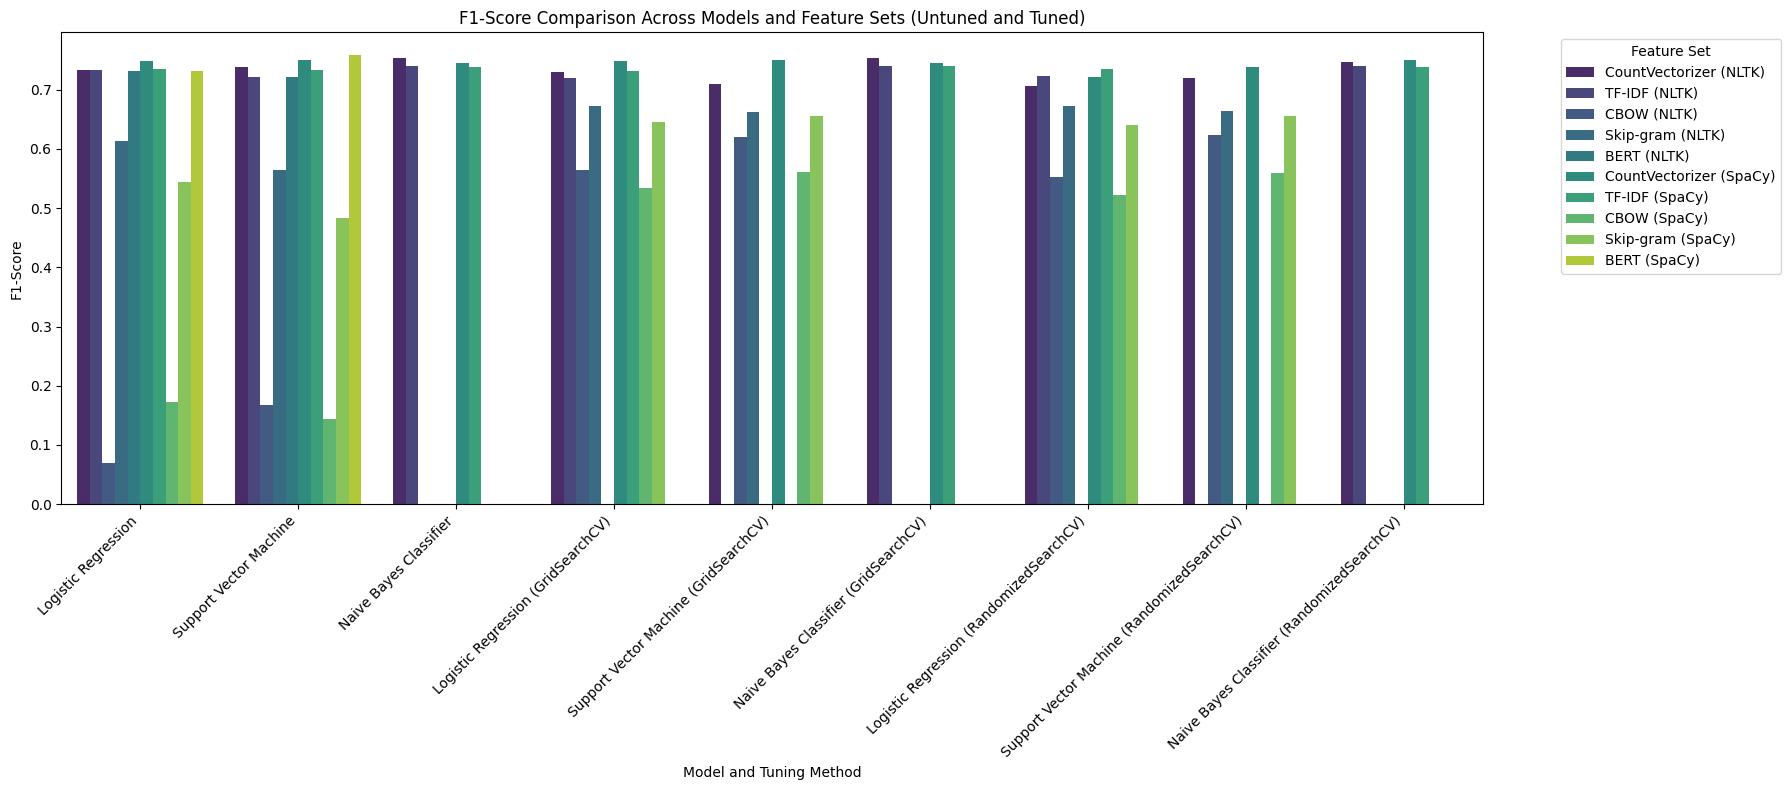

In [17]:
# Combine all results (untuned and tuned)
all_results = results_df.copy()
all_results['Model Type'] = 'Untuned'

tuned_results_gridsearch_df = pd.DataFrame(tuned_results_gridsearch)
tuned_results_gridsearch_df['Model Type'] = 'Tuned (GridSearchCV)'

tuned_results_randomsearch_df = pd.DataFrame(tuned_results_randomsearch)
tuned_results_randomsearch_df['Model Type'] = 'Tuned (RandomizedSearchCV)'


# Add the missing evaluation for the tuned models (GridSearchCV and RandomizedSearchCV)
# Iterate through the best estimators found during tuning
for model_feature_key, tuned_model in best_estimators_gridsearch.items():
    model_name, feature_set_name = model_feature_key.rsplit('_', 1)
    (X_train, X_test, y_train, y_test) = feature_sets[feature_set_name]

   # print(f"Evaluating Tuned Model (GridSearchCV): {model_name} on {feature_set_name}...")
    y_pred = tuned_model.predict(X_test)
   # accuracy, precision, recall, f1 = evaluate_model(y_test, y_pred, f"{model_name} (Tuned GridSearchCV)", feature_set_name)
    f1 = f1_score(y_test, y_pred)
    # Update the corresponding entry in tuned_results_gridsearch_df
    tuned_results_gridsearch_df.loc[
        (tuned_results_gridsearch_df['Model'].str.contains(model_name)) &
        (tuned_results_gridsearch_df['Feature Set'] == feature_set_name),
        ['F1-Score']
    ] = [f1]

for model_feature_key, tuned_model in best_estimators_randomsearch.items():
    model_name, feature_set_name = model_feature_key.rsplit('_', 1)
    (X_train, X_test, y_train, y_test) = feature_sets[feature_set_name]

   # print(f"Evaluating Tuned Model (RandomizedSearchCV): {model_name} on {feature_set_name}...")
    y_pred = tuned_model.predict(X_test)
   # accuracy, precision, recall, f1 = evaluate_model(y_test, y_pred, f"{model_name} (Tuned RandomizedSearchCV)", feature_set_name)
    f1 = f1_score(y_test, y_pred)
    # Update the corresponding entry in tuned_results_randomsearch_df
    tuned_results_randomsearch_df.loc[
        (tuned_results_randomsearch_df['Model'].str.contains(model_name)) &
        (tuned_results_randomsearch_df['Feature Set'] == feature_set_name),
        ['F1-Score']
    ] = [f1]


# Combine all results
all_results = pd.concat([all_results, tuned_results_gridsearch_df, tuned_results_randomsearch_df], ignore_index=True)

# Display the comprehensive summary
print("\n--- Comprehensive Summary of Model Performance (Untuned and Tuned) ---")
print(all_results.sort_values(by='F1-Score', ascending=False))
print('\n')

# Visualize performance metrics (e.g., F1-Score)
plt.figure(figsize=(18, 8))
sns.barplot(x='Model', y='F1-Score', hue='Feature Set', data=all_results, palette='viridis')
plt.title('F1-Score Comparison Across Models and Feature Sets (Untuned and Tuned)')
plt.xlabel('Model and Tuning Method')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Feature Set', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Visualization and Analysis**


*   Plot ROC curves and Precision-Recall curves for all models.
*   Display misclassified examples and analyze reasons for failure.
*   Visualize confusion matrices to understand classification errors.


--- Visualizing Model Performance ---
Analyzing performance for Logistic Regression with CountVectorizer (NLTK)...


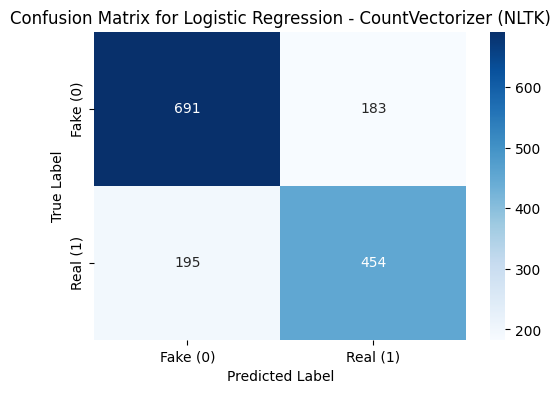


--- Misclassified Examples for CountVectorizer (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashe

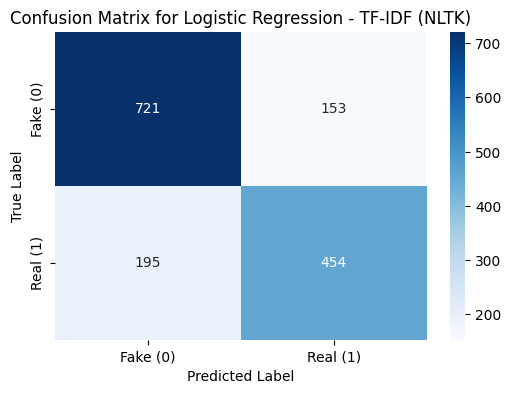


--- Misclassified Examples for TF-IDF (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKHAN #QUOTE
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Escape The Heat (and the #ORShow) for a trail run on Desolation Loop you'll be glad you di

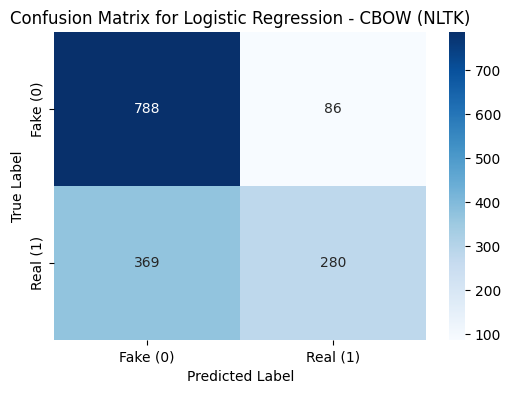


--- Misclassified Examples for CBOW (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr
  True Label: 1 (Real)
  Predi

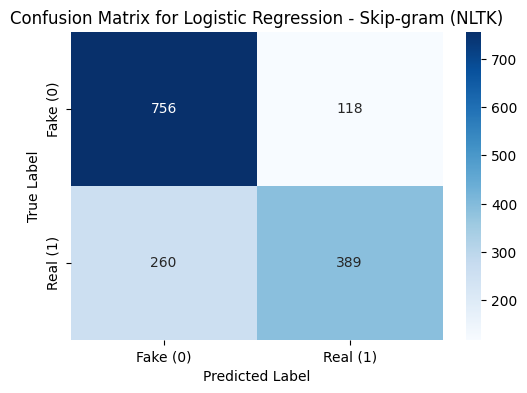


--- Misclassified Examples for Skip-gram (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr
  True Label: 1 (Real)
  

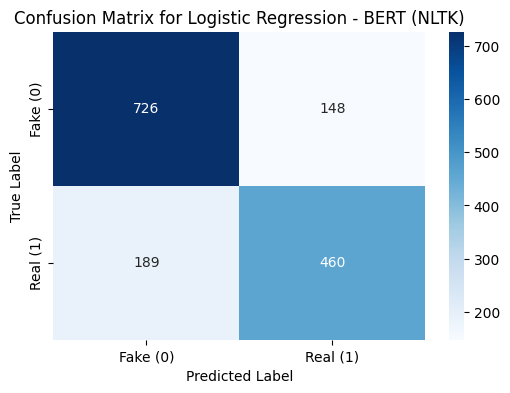


--- Misclassified Examples for BERT (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: AKILAH WORLD NEWS Cop pulls man from car to avoid this ... http://t.co/Vn2Fnmy7li
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: ON THE USE OF PERFORATED METAL SHEAR PANEL SFOR SEISMIC-RESISTANT APPLICATIONS http://t.co/cX5OjH2Dr4
  True Label: 0 (Fake)
  Predicted Label: 0 (F

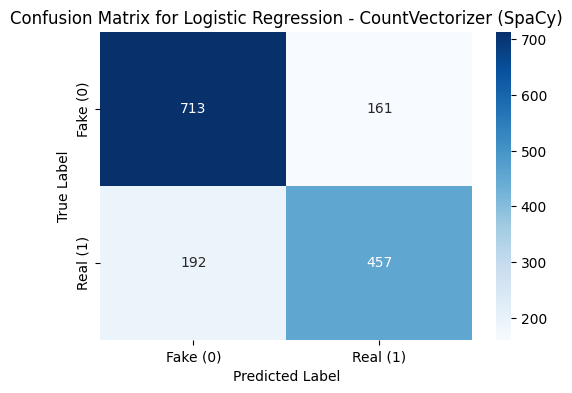


--- Misclassified Examples for CountVectorizer (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: @Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: AKILAH WORLD NEWS Cop pulls man from car to avoid this ... http://t.co/Vn2Fnmy7li
  True Label: 1 (Real)
  Predicte

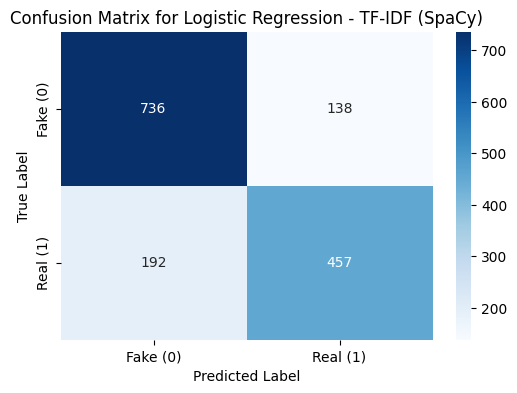


--- Misclassified Examples for TF-IDF (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: @Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: AKILAH WORLD NEWS Cop pulls man from car to avoid this ... http://t.co/Vn2Fnmy7li
  True Label: 1 (Real)
  Predicted Label: 

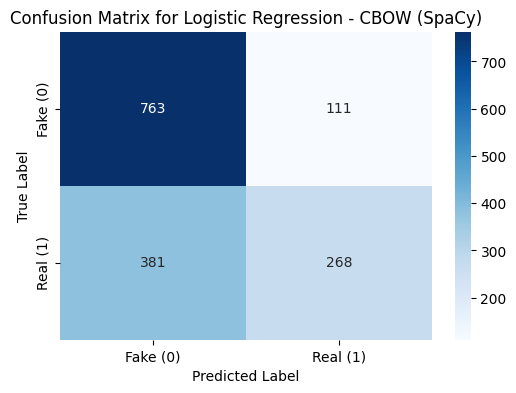


--- Misclassified Examples for CBOW (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Can't find my ariana grande shirt  this is a fucking tragedy
  True Label: 0 (Fake)
  Predicted Label: 

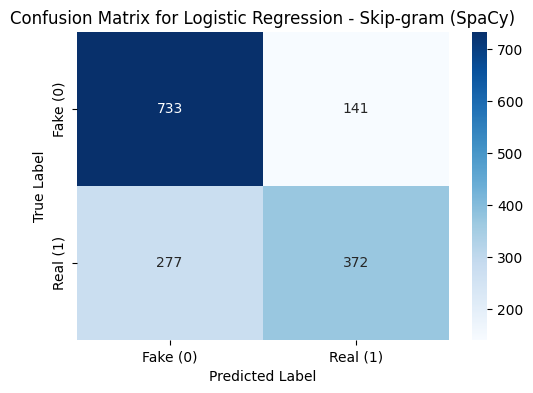


--- Misclassified Examples for Skip-gram (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Can't find my ariana grande shirt  this is a fucking tragedy
  True Label: 0 (Fake)
  Predicted La

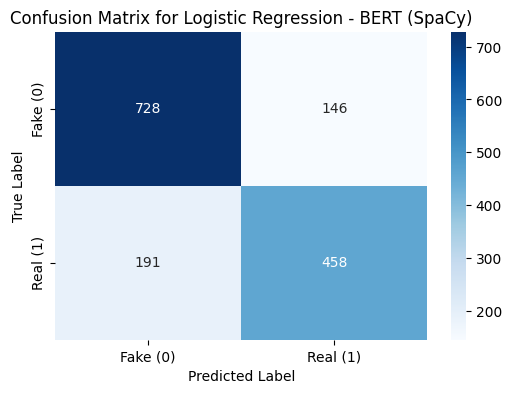


--- Misclassified Examples for BERT (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the P

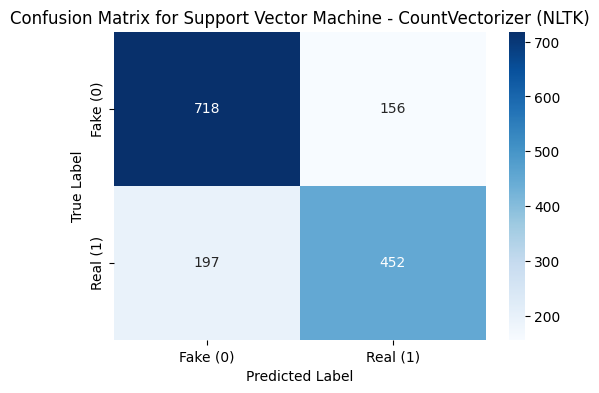


--- Misclassified Examples for CountVectorizer (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: @Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: @Zak_Bagans pets r like part of the family. I love animals.??? The last 2 pets I had I rescued! Breaks my heart when

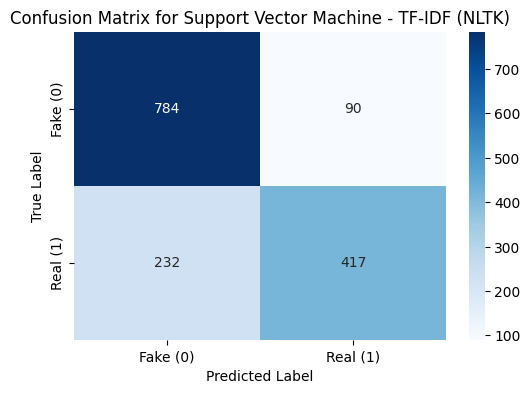


--- Misclassified Examples for TF-IDF (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKHAN #QUOTE
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: 4 kidnapped ladies rescued by police in Enugu | Nigerian Tribune http://t.co/xYyEV89WIz
  

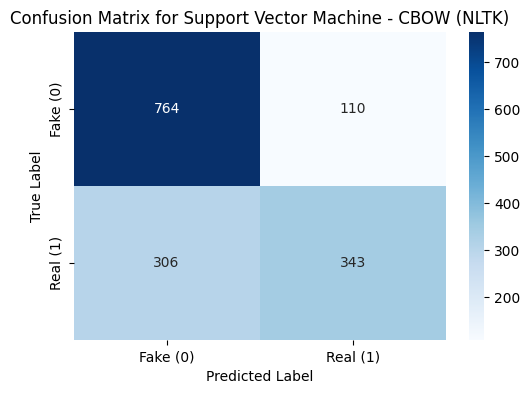


--- Misclassified Examples for CBOW (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr
  True Label: 1 (Real)
  Predi

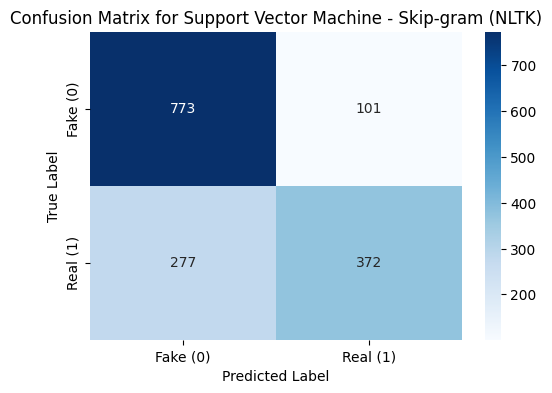


--- Misclassified Examples for Skip-gram (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America 

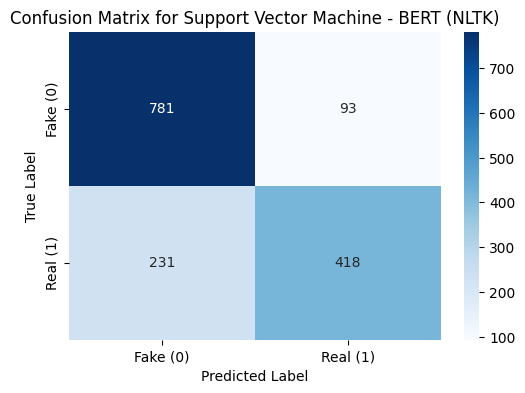


--- Misclassified Examples for BERT (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: ON THE USE OF PERFORATED METAL SHEAR PANEL SFOR SEISMIC-RESISTANT APPLICATIONS http://t.co/cX5OjH2Dr4
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKH

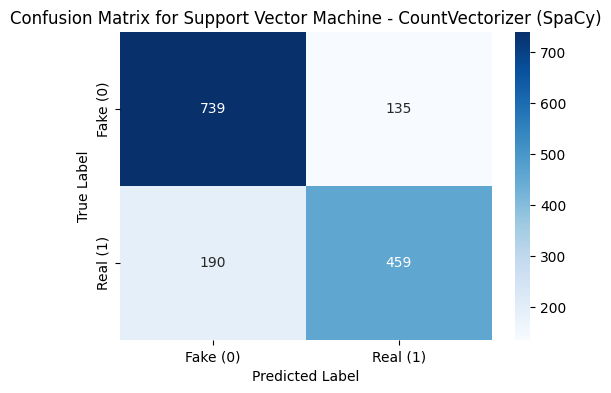


--- Misclassified Examples for CountVectorizer (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: @Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing h

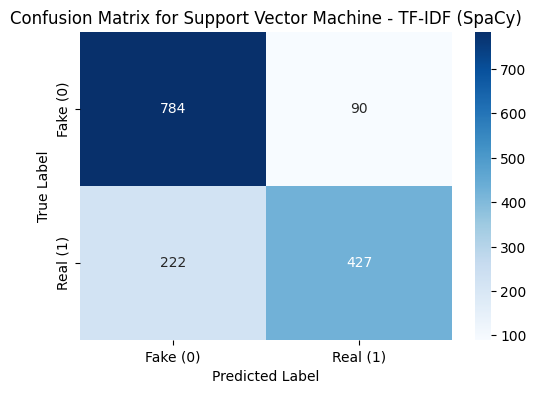


--- Misclassified Examples for TF-IDF (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKHAN #QUOTE
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: @BloopAndABlast Because I need to know if I'm supposed to throw myself off a bridge for a

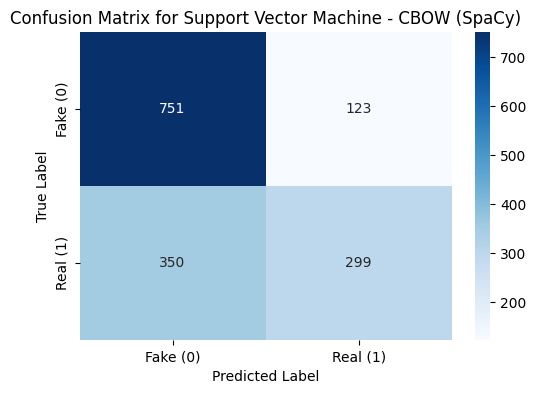


--- Misclassified Examples for CBOW (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Can't find my ariana grande shirt  this is a fucking tragedy
  True Label: 0 (Fake)
  Predicted Label: 

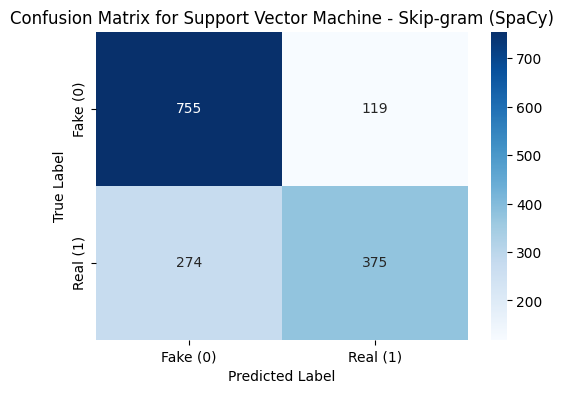


--- Misclassified Examples for Skip-gram (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Can't find my ariana grande shirt  this is a fucking tragedy
  True Label: 0 (Fake)
  Predicted La

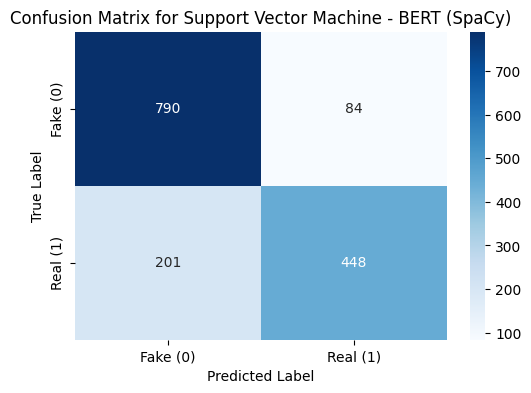


--- Misclassified Examples for BERT (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKHAN #QUOTE
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Escape The Heat (and the #ORShow) for a trail run on Desolation Loop you'll be glad you did

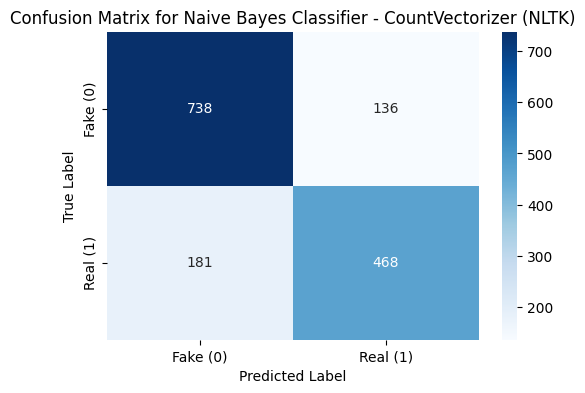


--- Misclassified Examples for CountVectorizer (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKHAN #QUOTE
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: @MyVintageSoul ...of the British upper class and his manservant.  The pampered we

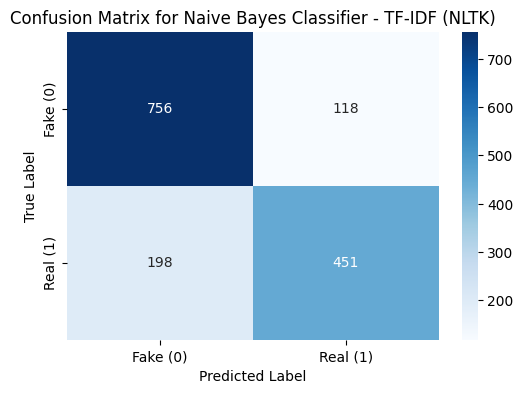


--- Misclassified Examples for TF-IDF (NLTK) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#FARRAKHAN #QUOTE
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: @MyVintageSoul ...of the British upper class and his manservant.  The pampered wealthy Bri

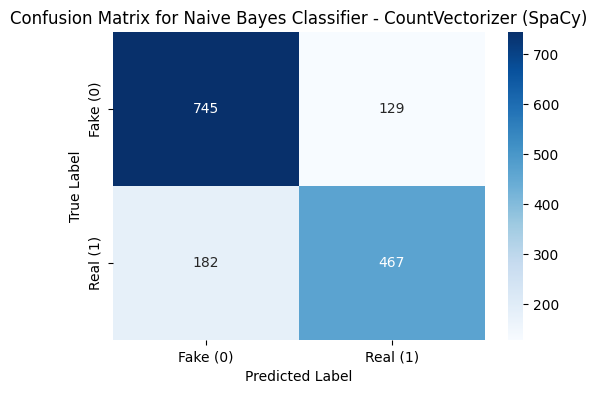


--- Misclassified Examples for CountVectorizer (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: @MyVintageSoul ...of the British upper class and his manservant.  The pampered wealthy Brit causes a catastrophic shift (reversal) of...
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: she's a suicide bomb
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)
---------

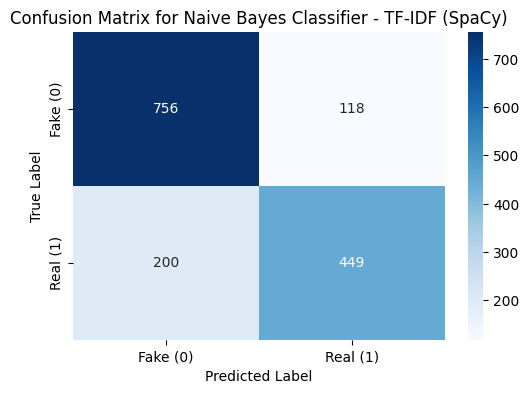


--- Misclassified Examples for TF-IDF (SpaCy) ---
Displaying 5 misclassified examples:

Example 1:
  Original Tweet: So you have a new weapon that can cause un-imaginable destruction.
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 2:
  Original Tweet: in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3
  True Label: 0 (Fake)
  Predicted Label: 0 (Fake)

Example 3:
  Original Tweet: my favorite lady came to our volunteer meeting
hopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS
  True Label: 1 (Real)
  Predicted Label: 1 (Real)

Example 4:
  Original Tweet: @brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS
  True Label: 1 (Real)
  Predicted Label: 0 (Fake)

Example 5:
  Original Tweet: Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her
 
#

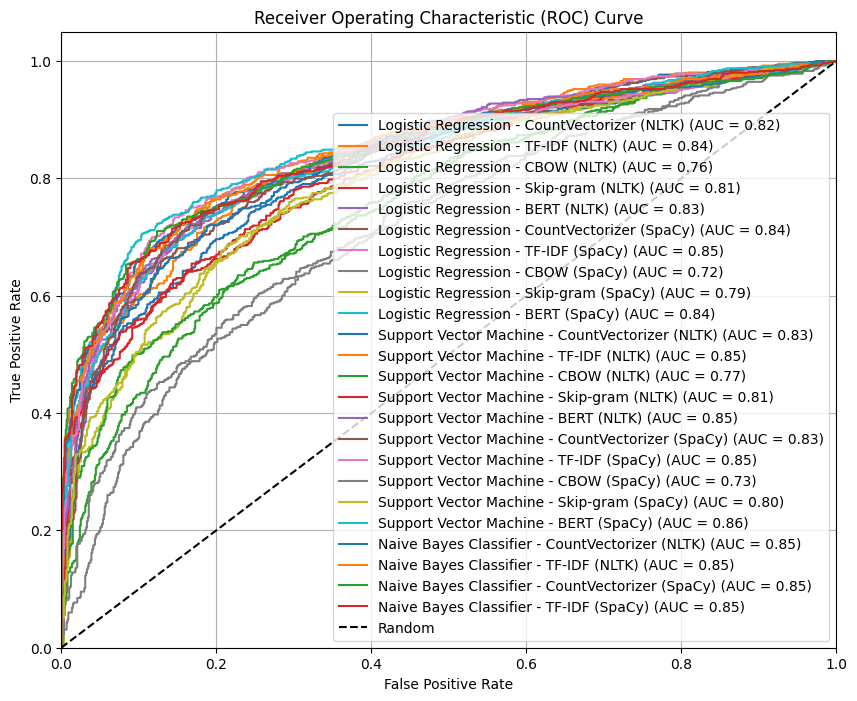

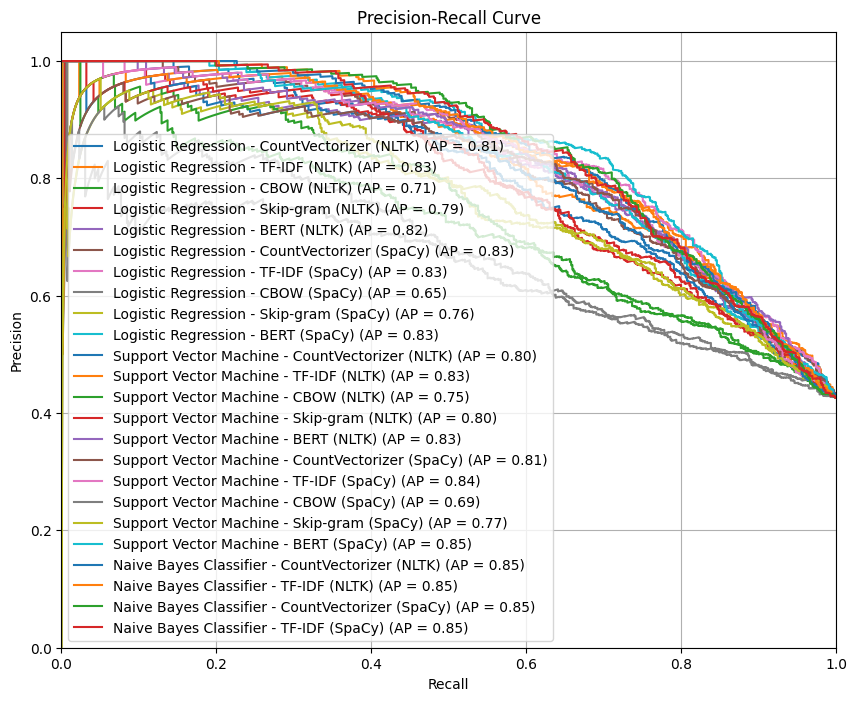


--- Visualization and Analysis Complete ---


In [18]:
# Function to plot ROC curve
def plot_roc_curve(y_test, y_probs, model_name, feature_set_name):
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} - {feature_set_name} (AUC = {roc_auc:.2f})')

# Function to plot Precision-Recall curve
def plot_pr_curve(y_test, y_probs, model_name, feature_set_name):
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    average_precision = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f'{model_name} - {feature_set_name} (AP = {average_precision:.2f})')

# Function to display confusion matrix
def plot_confusion_matrix(y_test, y_pred, model_name, feature_set_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake (0)', 'Real (1)'], yticklabels=['Fake (0)', 'Real (1)'])
    plt.title(f'Confusion Matrix for {model_name} - {feature_set_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Function to display misclassified examples
def display_misclassified(df, y_test, y_pred, feature_set_name, num_examples=5):
    if feature_set_name == 'CountVectorizer (NLTK)':
        _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'TF-IDF (NLTK)':
        _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'CBOW (NLTK)':
        _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'Skip-gram (NLTK)':
        _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'BERT (NLTK)':
        _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'CountVectorizer (SpaCy)':
         _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'TF-IDF (SpaCy)':
         _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'CBOW (SpaCy)':
         _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'Skip-gram (SpaCy)':
         _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    elif feature_set_name == 'BERT (SpaCy)':
         _, X_test, _, y_test_actual = train_test_split(df.index, y, test_size=0.2, random_state=42)
    else:
        return # Skip if feature set not handled

    misclassified_indices = X_test[y_test_actual != y_pred].tolist()

    print(f"\n--- Misclassified Examples for {feature_set_name} ---")
    if len(misclassified_indices) == 0:
        print("No misclassified examples found.")
        print("-" * 50)
        return

    print(f"Displaying {min(num_examples, len(misclassified_indices))} misclassified examples:")
    for i, original_index in enumerate(misclassified_indices[:num_examples]):
        original_tweet = df.loc[original_index]
        true_label = original_tweet['target']
        predicted_label = y_pred[i] # Use the index in y_pred relative to misclassified_indices

        print(f"\nExample {i+1}:")
        print(f"  Original Tweet: {original_tweet['text']}")
        print(f"  True Label: {true_label} ({'Real' if true_label == 1 else 'Fake'})")
        print(f"  Predicted Label: {predicted_label} ({'Real' if predicted_label == 1 else 'Fake'})")
        # You can add more analysis here, e.g., examine keywords, location, cleaned text

    print("-" * 50)

# Prepare lists for plotting ROC and PR curves
roc_curves_data = []
pr_curves_data = []

print("\n--- Visualizing Model Performance ---")

# Unified model dictionary: tuned or fallback to untuned
all_models_for_plotting = {}

for model_name, _ in models_to_tune.items():
  for feature_set_name, (X_train, X_test, y_train, y_test) in feature_sets.items():

    key = f"{model_name}_{feature_set_name}"
    tuned_model = best_estimators_randomsearch.get(key) or best_estimators_gridsearch.get(key)

    # Fallback to untuned model if tuning was skipped (due to time constraints)
    if not tuned_model:
        if model_name == 'Logistic Regression':
            fallback_model = LogisticRegression(max_iter=10000).fit(X_train, y_train)
        elif model_name == 'Support Vector Machine':
            fallback_model = SVC(probability=True).fit(X_train, y_train)
        elif model_name == 'Naive Bayes Classifier':
            if not (('CBOW' in feature_set_name) or ('Skip-gram' in feature_set_name) or ('BERT' in feature_set_name)):
                fallback_model = MultinomialNB().fit(X_train, y_train)
            else:
                continue
        else:
            continue
        all_models_for_plotting[key] = fallback_model
    else:
        all_models_for_plotting[key] = tuned_model

# Use models from unified dictionary
for key, model in all_models_for_plotting.items():
    model_name, feature_set_name = key.split('_', 1)
    X_train, X_test, y_train, y_test = feature_sets[feature_set_name]

    print(f"Analyzing performance for {model_name} with {feature_set_name}...")

    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_probs = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_probs = model.decision_function(X_test)
    else:
        y_probs = y_pred

    roc_curves_data.append((y_test, y_probs, model_name, feature_set_name))
    pr_curves_data.append((y_test, y_probs, model_name, feature_set_name))

    plot_confusion_matrix(y_test, y_pred, model_name, feature_set_name)
    display_misclassified(df, y_test, y_pred, feature_set_name)

# ROC CURVE
plt.figure(figsize=(10, 8))
for y_test, y_probs, model_name, feature_set_name in roc_curves_data:
    plot_roc_curve(y_test, y_probs, model_name, feature_set_name)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# PR CURVE
plt.figure(figsize=(10, 8))
for y_test, y_probs, model_name, feature_set_name in pr_curves_data:
     plot_pr_curve(y_test, y_probs, model_name, feature_set_name)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print("\n--- Visualization and Analysis Complete ---")



--- Full Model Performance Summary ---


,Model,Feature Set,Best Params,AUC,AP,Weighted Average
17,Support Vector Machine,BERT (SpaCy),Untuned,0.855781,0.851400,0.852714
5,Logistic Regression,CountVectorizer (SpaCy),"{'C': 1, 'class_weight': None, 'dual': False, ...",0.851926,0.848026,0.849196
18,Naive Bayes Classifier,CountVectorizer (NLTK),"{'alpha': 1.0, 'class_prior': None, 'fit_prior...",0.849492,0.849034,0.849171
20,Naive Bayes Classifier,CountVectorizer (SpaCy),"{'alpha': 1.0, 'class_prior': None, 'fit_prior...",0.846620,0.850200,0.849126
19,Naive Bayes Classifier,TF-IDF (NLTK),"{'alpha': 0.5, 'class_prior': None, 'fit_prior...",0.849478,0.847074,0.847795
21,Naive Bayes Classifier,TF-IDF (SpaCy),"{'alpha': 0.5, 'class_prior': None, 'fit_prior...",0.846339,0.846770,0.846641
0,Logistic Regression,CountVectorizer (NLTK),"{'C': 1, 'class_weight': None, 'dual': False, ...",0.847295,0.839339,0.841726
14,Support Vector Machine,CountVectorizer (SpaCy),"{'C': 1, 'break_ties': False, 'cache_size': 20...",0.847028,0.838025,0.840726
13,Support Vector Machine,BERT (NLTK),Untuned,0.846695,0.833297,0.837316
9,Logistic Regression,BERT (SpaCy),Untuned,0.835556,0.831753,0.832894


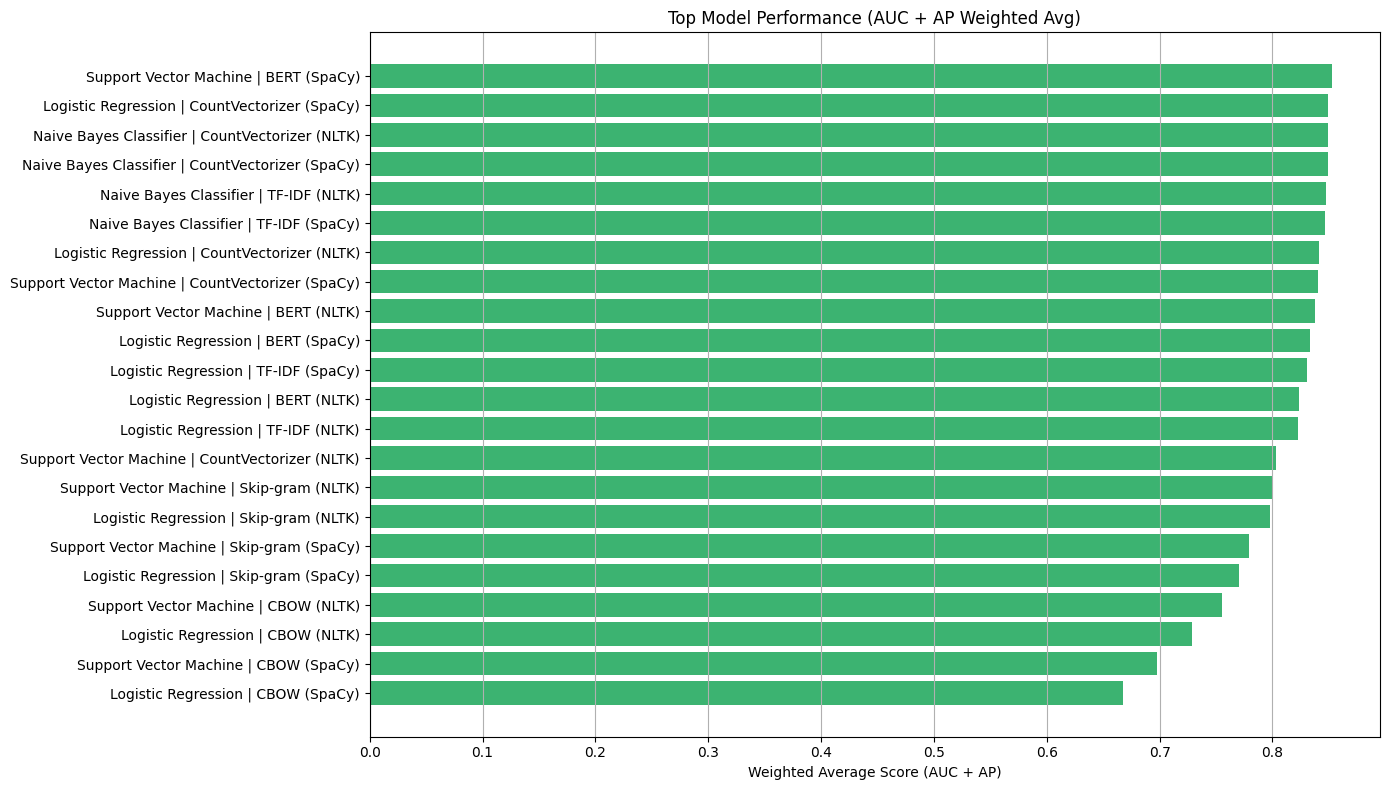


--- Top 3 Models Based on Weighted Average ---


,Model,Feature Set,Best Params,AUC,AP,Weighted Average
17,Support Vector Machine,BERT (SpaCy),Untuned,0.855781,0.851400,0.852714
5,Logistic Regression,CountVectorizer (SpaCy),"{'C': 1, 'class_weight': None, 'dual': False, ...",0.851926,0.848026,0.849196
18,Naive Bayes Classifier,CountVectorizer (NLTK),"{'alpha': 1.0, 'class_prior': None, 'fit_prior...",0.849492,0.849034,0.849171


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, average_precision_score

import warnings

# Initialize lists to collect performance data
all_auc_scores = []
all_ap_scores = []
all_model_names = []
all_feature_sets = []
all_best_params = []

# Loop through all models and feature sets
for model_name, model in models.items():
    for feature_set_name, (X_train, X_test, y_train, y_test) in feature_sets.items():

        # Skip incompatible combinations
        if model_name == 'Naive Bayes Classifier' and any(x in feature_set_name for x in ['BERT', 'CBOW', 'Skip-gram']):
            continue
        if model_name == 'Support Vector Machine' and 'TF-IDF' in feature_set_name:
            continue

        model_key = f"{model_name}_{feature_set_name}"

        # Use tuned model if available, otherwise fallback to untuned
        if model_key in best_estimators_gridsearch:
            best_model = best_estimators_gridsearch[model_key]
        elif model_key in best_estimators_randomsearch:
            best_model = best_estimators_randomsearch[model_key]
        else:
            if model_name == 'Logistic Regression':
                best_model = LogisticRegression(max_iter=10000).fit(X_train, y_train)
            elif model_name == 'Support Vector Machine':
                best_model = SVC(probability=True).fit(X_train, y_train)
            elif model_name == 'Naive Bayes Classifier':
                best_model = MultinomialNB().fit(X_train, y_train)
            else:
                continue  # Skip unknown models

        # Predict probabilities
        if hasattr(best_model, 'predict_proba'):
            y_probs = best_model.predict_proba(X_test)[:, 1]
        else:
            y_probs = best_model.decision_function(X_test)

        # Calculate AUC and AP
        auc_score = roc_auc_score(y_test, y_probs)
        ap_score = average_precision_score(y_test, y_probs)

        # Store metrics
        all_model_names.append(model_name)
        all_feature_sets.append(feature_set_name)
        all_auc_scores.append(auc_score)
        all_ap_scores.append(ap_score)

        # Best params info
        if model_key in best_estimators_gridsearch:
            best_params = best_estimators_gridsearch[model_key].get_params()
        elif model_key in best_estimators_randomsearch:
            best_params = best_estimators_randomsearch[model_key].get_params()
        else:
            best_params = "Untuned"
        all_best_params.append(best_params)

# Create DataFrame
model_performance_df = pd.DataFrame({
    'Model': all_model_names,
    'Feature Set': all_feature_sets,
    'Best Params': all_best_params,
    'AUC': all_auc_scores,
    'AP': all_ap_scores
})

# Weighted Average---- Not too much dfalse positive and its a imbalabced datesheet
model_performance_df['Weighted Average'] = (
    0.3 * model_performance_df['AUC'] +
    0.7 * model_performance_df['AP']
)

# Sort and Display
model_performance_sorted = model_performance_df.sort_values(by='Weighted Average', ascending=False)

print("\n--- Full Model Performance Summary ---")
display(model_performance_sorted[['Model', 'Feature Set', 'Best Params', 'AUC', 'AP', 'Weighted Average']])

# Bar Chart
plt.figure(figsize=(14, 8))
plt.barh(
    model_performance_sorted['Model'] + " | " + model_performance_sorted['Feature Set'],
    model_performance_sorted['Weighted Average'],
    color='mediumseagreen'
)
plt.xlabel('Weighted Average Score (AUC + AP)')
plt.title('Top Model Performance (AUC + AP Weighted Avg)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# Top 3 Models
print("\n--- Top 3 Models Based on Weighted Average ---")
top3 = model_performance_sorted.head(3)
display(top3[['Model', 'Feature Set', 'Best Params', 'AUC', 'AP', 'Weighted Average']])


# **Prediction on test set**




*   import test dataset
*   predict target
*   save it in a submission file

In [20]:
uploaded = files.upload()
df_test = pd.read_csv('test (1).csv')

# Inspect the structure
print('\n')
print("Test Dataset structure:")
df_test.info()
print('\n')

# Check for null values in test set
print("\nNull values per column in test set:")
print(df_test.isnull().sum())
print('\n')

# Handle missing data in test set (Example: fill missing location with 'unknown', keyword with 'none')
df_test['location'] = df_test['location'].fillna('unknown')
df_test['keyword'] = df_test['keyword'].fillna('none')

# just to recheck test set
print("Null values after handling in test set:")
print(df_test.isnull().sum())
print('\n')

Saving test (1).csv to test (1).csv


Test Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB



Null values per column in test set:
id             0
keyword       26
location    1105
text           0
dtype: int64


Null values after handling in test set:
id          0
keyword     0
location    0
text        0
dtype: int64




In [21]:
# Select the top 3 models based on the 'Weighted Average' calculated previously
top_models_info = model_performance_sorted.head(3)
top3 = top_models_info.index.tolist() # Get the indices of the top 3 models

# Function to preprocess test data based on the chosen preprocessing method
def preprocess_test_data(df_test, preprocessing_method):
  if preprocessing_method == 'NLTK':
    df_test['cleaned_text'] = df_test['text'].apply(preprocess_text_nltk)
    df_test['tokenized_text'] = df_test['cleaned_text'].str.split()
    return df_test['cleaned_text'], df_test['tokenized_text']
  elif preprocessing_method == 'SpaCy':
    df_test['cleaned_text'] = df_test['text'].apply(preprocess_text_spacy)
    df_test['tokenized_text'] = df_test['cleaned_text'].str.split()
    return df_test['cleaned_text'], df_test['tokenized_text']
  else:
    raise ValueError("Invalid preprocessing method")

# Function to vectorize test data based on the chosen vectorization method and preprocessing
def vectorize_test_data(cleaned_text, tokenized_text, feature_set_name):
  if 'CountVectorizer' in feature_set_name:
    # Use the fitted CountVectorizer from the training phase
    vectorizer = CountVectorizer(max_features=5000, min_df=2, max_df=0.97, stop_words='english')
    # Fit the vectorizer on the training data to ensure consistent vocabulary
    if 'NLTK' in feature_set_name:
        vectorizer.fit(df['cleaned_text_nltk'])
    elif 'SpaCy' in feature_set_name:
        vectorizer.fit(df['cleaned_text_spacy'])
    else:
        raise ValueError("Unknown preprocessing method for CountVectorizer")
    return vectorizer.transform(cleaned_text)

  elif 'TF-IDF' in feature_set_name:
    # Use the fitted TfidfVectorizer from the training phase
    vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.97, stop_words='english', sublinear_tf=True)
     # Fit the vectorizer on the training data to ensure consistent vocabulary
    if 'NLTK' in feature_set_name:
        vectorizer.fit(df['cleaned_text_nltk'])
    elif 'SpaCy' in feature_set_name:
        vectorizer.fit(df['cleaned_text_spacy'])
    else:
        raise ValueError("Unknown preprocessing method for TF-IDF")
    return vectorizer.transform(cleaned_text)

  elif 'CBOW' in feature_set_name:
    # Use the trained CBOW model from the training phase
    if 'NLTK' in feature_set_name:
        model = cbow_model_nltk
    elif 'SpaCy' in feature_set_name:
        model = cbow_model_spacy
    else:
        raise ValueError("Unknown preprocessing method for CBOW")
    return np.vstack([get_document_vector(tokens, model) for tokens in tokenized_text])

  elif 'Skip-gram' in feature_set_name:
    # Use the trained Skip-gram model from the training phase
    if 'NLTK' in feature_set_name:
        model = skipgram_model_nltk
    elif 'SpaCy' in feature_set_name:
        model = skipgram_model_spacy
    else:
        raise ValueError("Unknown preprocessing method for Skip-gram")
    return np.vstack([get_document_vector(tokens, model) for tokens in tokenized_text])

  elif 'BERT' in feature_set_name:
     # Use the BERT embedding function
     return get_bert_embeddings(cleaned_text.tolist())

  else:
    raise ValueError("Invalid feature set name")

# Create a dictionary to store predictions from the top 3 models
top_model_predictions = {}

print("\n--- Making Predictions with Top 3 Models ---")

# Iterate through the top 3 models
for idx in top3:
    model_info = model_performance_sorted.loc[idx]
    model_name = model_info['Model']
    feature_set_name = model_info['Feature Set']
    preprocessing_method = 'NLTK' if 'NLTK' in feature_set_name else 'SpaCy'
    # Skip problematic scenario
    if model_name == 'Support Vector Machine' and 'TF-IDF' in feature_set_name:
            continue
    if model_name == 'Naive Bayes Classifier' and any(x in feature_set_name for x in ['BERT', 'CBOW', 'Skip-gram']):
            continue

    print(f"\nPredicting with: {model_name} using {feature_set_name}")

    # 1. Preprocess test data based on the model's preprocessing method
    cleaned_text_test, tokenized_text_test = preprocess_test_data(df_test.copy(), preprocessing_method)

    # 2. Vectorize test data based on the model's feature set
    X_test_processed = vectorize_test_data(cleaned_text_test, tokenized_text_test, feature_set_name)

    # 3. Get the corresponding trained model (tuned or untuned fallback)
    model_key = f"{model_name}_{feature_set_name}"
    if model_key in best_estimators_gridsearch:
        trained_model = best_estimators_gridsearch[model_key]
    elif model_key in best_estimators_randomsearch:
        trained_model = best_estimators_randomsearch[model_key]
    else:
        # Fallback to untuned model if tuning was skipped
        X_train_fallback, _, y_train_fallback, _ = feature_sets[feature_set_name]

        # Important: Vectorize X_train_fallback using same vectorizer logic as test
        # cleaned_text_train = df['cleaned_text_nltk'] if 'NLTK' in feature_set_name else df['cleaned_text_spacy']
        # tokenized_text_train = cleaned_text_train.str.split()
        # X_train_processed = vectorize_test_data(cleaned_text_train, tokenized_text_train, feature_set_name)
        # y_train = feature_sets[feature_set_name][2]
        X_train_processed = X_train_fallback
        y_train = y_train_fallback
        if model_name == 'Logistic Regression':
            trained_model = LogisticRegression(max_iter=10000).fit(X_train_processed,y_train)
        elif model_name == 'Support Vector Machine':
            trained_model = SVC(probability=True).fit(X_train_processed,y_train)
        elif model_name == 'Naive Bayes Classifier':
            trained_model = MultinomialNB().fit(X_train_processed,y_train)
        elif model_name == 'Naive Bayes Classifier' and any(x in feature_set_name for x in ['BERT', 'CBOW', 'Skip-gram']):
            continue
        elif model_name == 'Support Vector Machine' and 'TF-IDF' in feature_set_name:
            continue
        else:
            print(f"Warning: Could not find a trained model for {model_name} with {feature_set_name}. Skipping.")
            continue


    # 4. Make predictions on the test data
    test_predictions = trained_model.predict(X_test_processed)

    # Store predictions
    top_model_predictions[f'{model_name}_{feature_set_name}'] = test_predictions

# Combine predictions from the top 3 models (e.g., majority voting)
# Here just show the predictions of each top model
print("\n--- Predictions from Top 3 Models ---")
for model_key, predictions in top_model_predictions.items():
    print(f"\nPredictions from {model_key}:")
    print(predictions[:20]) # Print first 20 predictions as an example


# to create a final prediction based on these models
# we could implement a majority voting system or weighted average of probabilities
from scipy.stats import mode

# Combine prediction from top models
if len(top_model_predictions) > 0:
    prediction_matrix = np.vstack(list(top_model_predictions.values())).T
    # weighted average of probability
    weights = top_models_info['Weighted Average'].values
    normalized_weights = weights / np.sum(weights) # Normalize so they sum to 1
    final_predictions = np.round(np.average(prediction_matrix, axis=1, weights = normalized_weights))
    final_predictions_avg = (final_predictions >= 0.5).astype(int)
    print("\n--- Final Predictions (Weighted Average) ---")
    print(final_predictions_avg[:20])
    # or
    # majority voting
    final_predictions_vote = mode(prediction_matrix, axis=1)[0].flatten()
    print("\n--- Final Predictions (Majority Voting) ---")
    print(final_predictions_vote[:20])

    # Create a submission DataFrame for wighted average of probability
    submission_df_avg = pd.DataFrame({'id': df_test['id'], 'target': final_predictions_avg})
    print("\nSample Submission DataFrame by weighted average of probability :")
    print(submission_df_avg.head())
    # Save the submission file
    submission_df_avg.to_csv('submission.csv.avg', index=False)
    print("\nSubmission file 'submission.csv.avg' created using majority voting.")
    # or
    # Create a submission DataFrame for majority voting
    submission_df_vote = pd.DataFrame({'id': df_test['id'], 'target': final_predictions_vote})
    print("\nSample Submission DataFrame by majority voting :")
    print(submission_df_vote.head())
    # Save the submission file
    submission_df_vote.to_csv('submission.csv.vote', index=False)
    print("\nSubmission file 'submission.csv.vote' created using majority voting.")



--- Making Predictions with Top 3 Models ---

Predicting with: Support Vector Machine using BERT (SpaCy)


Generating BERT Embeddings: 100%|██████████| 204/204 [03:53<00:00,  1.14s/it]



Predicting with: Logistic Regression using CountVectorizer (SpaCy)

Predicting with: Naive Bayes Classifier using CountVectorizer (NLTK)

--- Predictions from Top 3 Models ---

Predictions from Support Vector Machine_BERT (SpaCy):
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]

Predictions from Logistic Regression_CountVectorizer (SpaCy):
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0]

Predictions from Naive Bayes Classifier_CountVectorizer (NLTK):
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]

--- Final Predictions (Weighted Average) ---
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]

--- Final Predictions (Majority Voting) ---
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]

Sample Submission DataFrame by weighted average of probability :
   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1

Submission file 'submission.csv.avg' created using majority voting.

Sample Submission DataFrame by majority voting :
   id  target
0   0       1
1   2       1
2   3       1
3   9       1


## **Report error on sample submission file**

In [22]:
uploaded_sample = files.upload()
sample_submission_df = pd.read_csv('sample_submission.csv')

submission_df_avg = pd.read_csv('submission.csv.avg')
submission_df_vote = pd.read_csv('submission.csv.vote')

# Report errors by comparing with the sample_submission.csv

# Compare weighted average submission
merged_avg = pd.merge(submission_df_avg, sample_submission_df, on='id', suffixes=('_pred', '_sample'))
error_avg = merged_avg[merged_avg['target_pred'] != merged_avg['target_sample']]
print("\nErrors in 'submission.csv.avg' compared to 'sample_submission.csv':")
if error_avg.empty:
    print("No errors found.")
else:
    print(f"Found {len(error_avg)/len(merged_avg):.3%} error.\n")
print('-'*100)

# Compare majority voting submission
merged_vote = pd.merge(submission_df_vote, sample_submission_df, on='id', suffixes=('_pred', '_sample'))
error_vote = merged_vote[merged_vote['target_pred'] != merged_vote['target_sample']]
print("\nErrors in 'submission.csv.vote' compared to 'sample_submission.csv':")
if error_vote.empty:
    print("No errors found.")
else:
    print(f"Found {len(error_vote)/len(merged_vote):.3%} errors.")

Saving sample_submission.csv to sample_submission.csv

Errors in 'submission.csv.avg' compared to 'sample_submission.csv':
Found 35.152% error.

----------------------------------------------------------------------------------------------------

Errors in 'submission.csv.vote' compared to 'sample_submission.csv':
Found 35.152% errors.


In [3]:
print (  'So from the learning model we find out'
         '\n Logistic Regression through CountVectorizer as vectorizer, Spacy as text preprocessing function;',
         '\n Naive Bayes Classifier throuugh CountVectorizer as vectorizer, NLTK as text preprocessing function;',
         '\n Naive Bayes Classifier throuugh CountVectorizer as vectorizer, Spacy as text preprocessing function;',
         '\nacts as best',
         '\nand in case for choosing Prediction Method both Voting and MaxProbability both work as SAME.' )

So from the learning model we find out
 Logistic Regression through CountVectorizer as vectorizer, Spacy as text preprocessing function; 
 Naive Bayes Classifier throuugh CountVectorizer as vectorizer, NLTK as text preprocessing function; 
 Naive Bayes Classifier throuugh CountVectorizer as vectorizer, Spacy as text preprocessing function; 
acts as best 
and in case for choosing Prediction Method both Voting and MaxProbability both work as SAME.
